<div align="center">
  <h1><b>Analisa Dataset NYC TLC Trip Record</b></h1>
   <b>Wafa Nabila</b>
</div>


<style>
  body, html {
    height: 100%;
    margin: 0;
  }

  .container {
    display: flex;
    justify-content: center;  /* Horizontal center */
    align-items: center;      /* Vertical center */
    height: 100vh;            /* Full viewport height */
  }

  img {
    width: 100%;              /* Gambar memenuhi lebar */
    height: 100%;             /* Gambar memenuhi tinggi */
    object-fit: cover;       /* Memastikan gambar tetap terjaga proporsinya */
  }
</style>

<div align="center">
  <img src="taxinyc.jpg" alt="Taksi New York">
</div>

# Pendahuluan


Dataset NYC TLC Trip Record berisi catatan perjalanan taksi yang dikelola oleh New York City Taxi and Limousine Commission (NYC TLC). 
Dataset ini berisi informasi rinci mengenai perjalanan taksi di seluruh kota New York, termasuk waktu dan lokasi penjemputan serta pengantaran, tarif, jumlah penumpang. Dengan menggunakan dataset ini, berbagai analisis dapat dilakukan untuk memperoleh informasi mengenai pola perjalanan, zona, tren tarif, dan perilaku penumpang.

Penelitian dan analisis terhadap data ini dapat memberikan manfaat yang besar, seperti pengoptimalan rute taksi, peningkatan pengalaman penumpang, serta pemahaman tentang faktor-faktor yang memengaruhi harga dan permintaan layanan taksi.

## Latar Belakang

NYC TLC (New York City Taxi and Limousine Commission) adalah lembaga pemerintah yang bertanggung jawab mengatur dan mengawasi layanan transportasi umum di New York City, termasuk taksi, layanan limusin, kendaraan penyewaan (seperti Uber dan Lyft), serta armada kendaraan lainnya yang beroperasi di kota tersebut. NYC TLC dibentuk pada tahun 1971 dengan tujuan untuk menciptakan sistem transportasi yang aman, efisien, dan adil bagi penduduk serta pengunjung New York City.

Tugas dan Fungsi NYC TLC meliputi:

- **Regulasi dan Pengawasan:** NYC TLC mengatur operasional taksi dan kendaraan sewa, termasuk menentukan tarif, lisensi pengemudi, dan prosedur keselamatan. Mereka juga memastikan bahwa kendaraan yang beroperasi memenuhi standar kebersihan dan kenyamanan.

- **Pemberian Lisensi:** NYC TLC memberikan lisensi kepada pengemudi taksi dan penyedia layanan transportasi lainnya, serta mengawasi proses perizinan kendaraan yang digunakan untuk transportasi umum.

- **Keamanan dan Perlindungan Konsumen:** NYC TLC bertanggung jawab untuk memastikan bahwa pengemudi dan penumpang dilindungi dengan memastikan adanya regulasi yang ketat terkait keselamatan perjalanan, seperti pemeriksaan kendaraan, pemeriksaan latar belakang pengemudi, serta memastikan adanya asuransi yang memadai.

- **Meningkatkan Aksesibilitas:** NYC TLC bekerja untuk meningkatkan aksesibilitas layanan transportasi, termasuk memastikan adanya kendaraan yang dapat diakses oleh penumpang dengan disabilitas.

- **Pengelolaan Data dan Statistik:** NYC TLC juga mengumpulkan dan mengelola data terkait perjalanan taksi dan layanan transportasi lainnya. Data ini digunakan untuk menganalisis tren transportasi, permintaan, dan efisiensi operasional serta merumuskan kebijakan yang lebih baik.

Secara keseluruhan, NYC TLC berperan penting dalam menciptakan sistem transportasi yang berkelanjutan dan terpercaya di New York City, dengan tujuan utama memastikan bahwa layanan transportasi umum dapat diakses secara aman dan adil oleh semua pengguna.

## Pernyataan Masalah

Dalam analisis data NYC TLC Trip Record kali ini, terdapat beberapa fokus utama yang akan saya analisis untuk mendapatkan informasi yang lebih mendalam mengenai operasional taksi di New York City. Fokus masalah tersebut adalah sebagai berikut:

**1. Identifikasi Pola Waktu Sibuk Pada Setiap Borough**  
Analisis ini bertujuan untuk menggali pola waktu sibuk pada tiap borough di New York City. Dengan memanfaatkan data waktu penjemputan dan penurunan, serta zona penjemputan dan penurunan, analisis ini akan memberikan gambaran yang lebih jelas tentang waktu-waktu tertentu yang memiliki permintaan tinggi. Wawasan ini akan sangat berguna bagi stakeholder (seperti operator taksi dan perusahaan transportasi) untuk memaksimalkan pelayanan pada jam sibuk dan untuk merencanakan distribusi armada taksi yang lebih efisien di zona-zona yang padat.

**2. Identifikasi Daerah dengan Tingkat Kemacetan yang Tinggi**  
Penting untuk mengetahui area tertentu yang memiliki tingkat kemacetan yang tinggi agar strategi transportasi dapat disesuaikan dengan kondisi tersebut. Analisis ini akan melibatkan pemetaan perjalanan berdasarkan data lokasi penjemputan dan pengantaran untuk mengidentifikasi area yang cenderung mengalami kepadatan lalu lintas. Informasi ini akan membantu pengelola taksi dan pemangku kebijakan dalam merencanakan solusi untuk mengurangi kemacetan dan meningkatkan efisiensi perjalanan.

**3. Analisis Jumlah Tip**  
Aspek lain yang akan dianalisis adalah perilaku penumpang dalam memberikan tip kepada pengemudi. Dengan memanfaatkan data terkait jumlah tip yang diberikan, analisis ini akan menggali pola perilaku penumpang, seperti faktor-faktor yang memengaruhi besarnya tip, apakah berkaitan dengan durasi perjalanan, waktu, jarak, atau kondisi tertentu lain.

**Import Modul-Modul Komplementer**

In [8]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import missingno as msno

import plotly

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.stats import kstest

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import folium
import geocoder

from folium.plugins import MarkerCluster, HeatMap
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

pd.set_option('display.max_rows', 50)

## Deskripsi Dataset

**Membaca Data**

In [11]:
df = pd.read_csv('NYC TLC Trip Record.csv')
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.90,1.0,0.5,4.03,0.0,NaN,1.0,24.18,1.0,1.0,2.75
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.70,1.0,0.5,2.64,0.0,NaN,1.0,15.84,1.0,1.0,0.00
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.20,1.0,0.5,1.94,0.0,NaN,1.0,11.64,1.0,1.0,0.00
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.50,0.5,1.5,1.70,0.0,NaN,1.0,10.20,1.0,1.0,0.00
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.00,0.5,1.5,0.00,0.0,NaN,1.0,8.00,1.0,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,NaN,NaN,49,62,NaN,4070.82,15.70,0.0,0.0,0.00,0.0,NaN,1.0,16.70,NaN,NaN,NaN
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,NaN,10,205,NaN,2.14,4.41,0.0,0.0,0.00,0.0,NaN,1.0,5.41,NaN,NaN,NaN
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,NaN,66,37,NaN,3.44,16.53,0.0,0.0,3.51,0.0,NaN,1.0,21.04,NaN,NaN,NaN
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,NaN,225,189,NaN,3.03,14.98,0.0,0.0,3.20,0.0,NaN,1.0,19.18,NaN,NaN,NaN


**Menambahkan Data Eksternal**

Untuk mendapatkan informasi mengenai nama zona secara lebih akurat, saya menambahkan data yang dapat diakses melalui website resmi [di sini](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)


In [13]:
df_zone = pd.read_csv("taxi_zone_lookup.csv")
df_zone

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
...,...,...,...,...
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,NaN,NaN


In [14]:
# Gabungkan kolom untuk Pickup Location
df = pd.merge(df, df_zone, left_on='PULocationID', right_on='LocationID', how='left', suffixes=('', '_pickup'))
df.rename(columns={'Zone': 'PUZone', 'Borough': 'Pickup_Borough', 'service_zone': 'service_zone_pickup'}, inplace=True)
df.drop(columns=['LocationID', 'service_zone_pickup'], inplace=True)

# Gabungkan kolom untuk Dropoff Location
df = pd.merge(df, df_zone, left_on='DOLocationID', right_on='LocationID', how='left', suffixes=('', '_dropoff'))
df.rename(columns={'Zone': 'DOZone', 'Borough': 'Dropoff_Borough', 'service_zone': 'service_zone_dropoff'}, inplace=True)
df.drop(columns=['LocationID', 'service_zone_dropoff'], inplace=True)

# Periksa hasil
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,Pickup_Borough,PUZone,Dropoff_Borough,DOZone
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.90,...,NaN,1.0,24.18,1.0,1.0,2.75,Manhattan,Morningside Heights,Manhattan,Lincoln Square West
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.70,...,NaN,1.0,15.84,1.0,1.0,0.00,Manhattan,Bloomingdale,Manhattan,Central Park
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0,223,179,1.0,0.00,7.20,...,NaN,1.0,11.64,1.0,1.0,0.00,Queens,Steinway,Queens,Old Astoria
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.50,...,NaN,1.0,10.20,1.0,1.0,0.00,Manhattan,Central Harlem,Manhattan,Upper West Side North
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.00,...,NaN,1.0,8.00,1.0,1.0,0.00,Manhattan,Central Harlem,Manhattan,East Harlem North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,NaN,NaN,49,62,NaN,4070.82,15.70,...,NaN,1.0,16.70,NaN,NaN,NaN,Brooklyn,Clinton Hill,Brooklyn,Crown Heights South
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,NaN,10,205,NaN,2.14,4.41,...,NaN,1.0,5.41,NaN,NaN,NaN,Queens,Baisley Park,Queens,Saint Albans
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,NaN,66,37,NaN,3.44,16.53,...,NaN,1.0,21.04,NaN,NaN,NaN,Brooklyn,DUMBO/Vinegar Hill,Brooklyn,Bushwick South
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,NaN,225,189,NaN,3.03,14.98,...,NaN,1.0,19.18,NaN,NaN,NaN,Brooklyn,Stuyvesant Heights,Brooklyn,Prospect Heights


# Pemahaman Data

## Deskripsi Kolom

Dataset berisi informasi mengenai detail rekaman perjalanan Taxi di New York.
Terdapat 20 kolom pada dataset NYC TLC Trip Record yang dapat digolongkan berdasarkan karakteristiknya, yaitu:

1. Identifikasi
   - `VendorID`: Identitas penyedia teknologi yang bertanggung jawab untuk mengumpulkan dan mengirimkan catatan perjalanan ke Komisi Taksi dan Limusin NYC (TLC).
     - 1: Creative Mobile Technologies, LLC.
     - 2: VeriFone Inc.
   - `RatecodeID`: Kode jenis tarif perjalanan.
     - 1: Tarif standar
     - 2: JFK (bandara)
     - 3: Newark (bandara)
     - 4: Nassau atau Westchester
     - 5: Tarif yang dinegosiasikan
     - 6: Perjalanan berkelompok
2. Informasi Waktu dan Tanggal
   - `lpep_pickup_datetime`: Tanggal dan waktu saat argometer diaktifkan.
   - `lpep_dropoff_datetime`: Tanggal dan waktu saat argometer dinon-aktifkan.
3. Informasi Lokasi
   - `PULocationID`: ID lokasi argometer diaktifkan (zona taksi)
   - `DOLocationID`: ID lokasi argometer dinon-aktifkan (zona taksi)
   - `Dropoff_Borough` : Deskripsi: Borough tempat penumpang diturunkan.
   - `DOZone` : Zona spesifik tempat penumpang diturunkan dalam borough tertentu.
   - `service_zone_dropoff` : Jenis layanan untuk zona dropoff, misalnya apakah termasuk dalam zona Yellow Zone, Boro Zone, atau Airports.
   - `Pickup_Borough` : Borough tempat penumpang dijemput.
   - `PUZone` : Zona spesifik tempat penumpang dijemput dalam borough tertentu.
   - `service_zone_pickup` : Jenis layanan untuk zona pickup.
4. Karakteristik Perjalanan
   - `passenger_count`: Jumlah penumpang dalam perjalanan.
   - `trip_distance`: Jarak perjalanan yang ditempuh (dalam mil).
   - `trip_type`: Kode yang menunjukkan apakah perjalanan tersebut adalah pemanggilan di jalan (street hail) atau pesanan taksi (dispatch).
     - 1: Pemanggilan di jalan
     - 2: Pemesanan taksi
6. Data Keuangan
   - Tarif dan Biaya Tambahan
     - `fare_amount`: Tarif dasar perjalanan.
     - `extra`: Biaya tambahan (seperti pada jam sibuk atau malam hari)
     - `mta_tax`: Pajak yang akan dibayarkan ke MTA, nilai ini tetap sebesar \$0.50.
     - `improvement_surcharge`: Biaya perbaikan sebesar \$0.30.
     - `tolls_amount`: Biaya tol yang dibayarkan selama perjalanan.
     - `congestion_surcharge`: Biaya tambahan untuk kemacetan.
   - Pembayaran
     - `tip_amount`: Tip yang diberikan penumpang. Kolom ini otomatis terisi untuk tips kartu kredit. Tips tunai tidak termasuk.
     - `total_amount`: Jumlah total yang dibebankan kepada penumpang. Tidak termasuk tip berupa uang tunai.
     - `payment_type`: Kode numerik yang menunjukkan metode pembayaran yang digunakan.
       - 1: Kartu kredit
       - 2: Tunai
       - 3: Bebas biaya
       - 4: Dipertanyakan
       - 5: Tidak diketahui
       - 6: Perjalanan dibatalkan
7. Data lain-lain
   - `store_and_fwd_flag`: Informasi apakah data disimpan sementara di kendaraan sebelum dikirim atau langsung dikirimkan ke server.
     - Y: perjalanan yang datanya disimpan dan diteruskan.
     - N: perjalanan yang datanya tidak disimpan dan diteruskan. 
   - `ehail_fee`: Biaya layanan pemesanan elektronik.

**Cek Jumlah Baris & Kolom**

In [19]:
print(f'''
Jumlah baris pada dataset: {df.shape[0]}
Jumlah kolom pada dataset: {df.shape[1]}
''')


Jumlah baris pada dataset: 68211
Jumlah kolom pada dataset: 24



**Cek Tipe Data Pada Setiap Kolom**

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68211 entries, 0 to 68210
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               68211 non-null  int64  
 1   lpep_pickup_datetime   68211 non-null  object 
 2   lpep_dropoff_datetime  68211 non-null  object 
 3   store_and_fwd_flag     63887 non-null  object 
 4   RatecodeID             63887 non-null  float64
 5   PULocationID           68211 non-null  int64  
 6   DOLocationID           68211 non-null  int64  
 7   passenger_count        63887 non-null  float64
 8   trip_distance          68211 non-null  float64
 9   fare_amount            68211 non-null  float64
 10  extra                  68211 non-null  float64
 11  mta_tax                68211 non-null  float64
 12  tip_amount             68211 non-null  float64
 13  tolls_amount           68211 non-null  float64
 14  ehail_fee              0 non-null      float64
 15  im

> Saya akan mengubah tipe beberapa data agar lebih representatif dengan jenis datanya.
> Seperti kolom yang berfungsi mengidentifikasi dengan nomor, dari jenis data *integer* diubah menjadi *object*.
> Kemudian untuk data berupa tanggal dan waktu dapat diubah menjadi tipe data *datetime*.

In [23]:
df = df.astype({'VendorID': 'object',
                'RatecodeID': 'object', 
                'PULocationID': 'object', 
                'DOLocationID': 'object', 
                'payment_type': 'object', 
                'trip_type': 'object'})
df['lpep_pickup_datetime'] = pd.to_datetime(df['lpep_pickup_datetime'])
df['lpep_dropoff_datetime'] = pd.to_datetime(df['lpep_dropoff_datetime'])

**Cek Unique Value Pada Setiap Kolom**

In [25]:
pd.set_option('display.max_colwidth', None)

listItem = []
for col in df.columns :
    listItem.append( [col, df[col].nunique(), df[col].unique()])

tabel1Desc = pd.DataFrame(columns=['Nama Kolom', 'Jumlah Unique Value', 'Sampel Unique Value'],
                     data=listItem)
tabel1Desc

,Nama Kolom,Jumlah Unique Value,Sampel Unique Value
0,VendorID,2,"[2, 1]"
1,lpep_pickup_datetime,66575,"[2023-01-01 00:26:10, 2023-01-01 00:51:03, 2023-01-01 00:35:12, 2023-01-01 00:13:14, 2023-01-01 00:33:04, 2023-01-01 00:53:31, 2023-01-01 00:09:14, 2023-01-01 00:11:58, 2023-01-01 00:41:29, 2023-01-01 00:50:32, 2023-01-01 00:16:12, 2023-01-01 00:08:43, 2023-01-01 00:26:32, 2023-01-01 00:18:35, 2023-01-01 00:39:32, 2023-01-01 00:49:34, 2023-01-01 00:10:45, 2023-01-01 00:35:11, 2023-01-01 00:31:06, 2023-01-01 00:14:37, 2023-01-01 00:26:21, 2023-01-01 00:41:56, 2023-01-01 00:32:02, 2023-01-01 00:55:13, 2023-01-01 00:01:31, 2023-01-01 00:22:31, 2023-01-01 00:57:28, 2023-01-01 00:35:21, 2023-01-01 00:52:52, 2023-01-01 00:32:56, 2023-01-01 00:24:01, 2023-01-01 00:46:48, 2023-01-01 00:40:58, 2023-01-01 00:20:23, 2023-01-01 01:49:24, 2023-01-01 00:41:53, 2023-01-01 00:56:26, 2023-01-01 00:33:10, 2023-01-01 00:58:28, 2023-01-01 00:42:49, 2023-01-01 00:48:21, 2023-01-01 00:08:05, 2023-01-01 00:13:47, 2023-01-01 00:16:10, 2023-01-01 00:04:25, 2023-01-01 00:33:38, 2023-01-01 00:46:08, 2023-01-01 01:00:08, 2023-01-01 00:28:04, 2023-01-01 00:23:04, 2023-01-01 00:34:07, 2023-01-01 00:52:03, 2023-01-01 00:25:31, 2023-01-01 00:53:09, 2023-01-01 00:42:37, 2023-01-01 00:39:52, 2023-01-01 00:15:32, 2023-01-01 00:06:48, 2023-01-01 00:57:15, 2023-01-01 00:14:13, 2023-01-01 00:52:48, 2023-01-01 00:34:13, 2023-01-01 00:44:41, 2023-01-01 00:11:12, 2023-01-01 01:44:43, 2023-01-01 01:04:44, 2023-01-01 01:48:11, 2023-01-01 01:11:39, 2023-01-01 01:54:25, 2023-01-01 01:59:10, 2023-01-01 01:22:35, 2023-01-01 01:37:10, 2023-01-01 01:46:22, 2023-01-01 01:59:48, 2023-01-01 01:09:49, 2023-01-01 01:23:35, 2023-01-01 01:53:20, 2023-01-01 01:32:14, 2023-01-01 01:01:05, 2023-01-01 01:34:41, 2023-01-01 01:52:08, 2023-01-01 01:49:28, 2023-01-01 01:03:59, 2023-01-01 01:13:11, 2023-01-01 01:40:06, 2023-01-01 01:33:50, 2023-01-01 01:45:19, 2023-01-01 01:51:29, 2023-01-01 01:34:07, 2023-01-01 01:10:08, 2023-01-01 01:32:17, 2023-01-01 01:48:28, 2023-01-01 01:30:43, 2023-01-01 01:51:10, 2023-01-01 01:09:36, 2023-01-01 01:19:54, 2023-01-01 01:31:10, 2023-01-01 01:42:30, 2023-01-01 00:57:51, 2023-01-01 01:27:36, ...]"
2,lpep_dropoff_datetime,66519,"[2023-01-01 00:37:11, 2023-01-01 00:57:49, 2023-01-01 00:41:32, 2023-01-01 00:19:03, 2023-01-01 00:39:02, 2023-01-01 01:11:04, 2023-01-01 00:26:39, 2023-01-01 00:24:55, 2023-01-01 00:46:26, 2023-01-01 01:13:42, 2023-01-01 00:41:43, 2023-01-01 00:17:08, 2023-01-01 00:45:31, 2023-01-01 00:30:09, 2023-01-01 01:18:06, 2023-01-01 01:08:23, 2023-01-01 00:19:37, 2023-01-01 01:17:35, 2023-01-01 00:42:23, 2023-01-01 00:21:50, 2023-01-01 00:30:26, 2023-01-01 00:46:06, 2023-01-01 00:41:25, 2023-01-01 00:59:47, 2023-01-01 00:16:02, 2023-01-01 00:39:24, 2023-01-01 01:09:31, 2023-01-01 00:53:49, 2023-01-01 01:00:53, 2023-01-01 00:42:53, 2023-01-01 00:32:05, 2023-01-01 01:08:17, 2023-01-01 01:04:32, 2023-01-01 00:24:32, 2023-01-01 01:57:51, 2023-01-01 00:41:58, 2023-01-01 01:14:41, 2023-01-01 00:43:08, 2023-01-01 01:14:46, 2023-01-01 00:51:53, 2023-01-01 01:23:50, 2023-01-01 00:13:26, 2023-01-01 00:25:57, 2023-01-01 00:54:55, 2023-01-01 00:17:50, 2023-01-01 00:38:51, 2023-01-01 00:59:10, 2023-01-01 01:05:46, 2023-01-01 00:43:45, 2023-01-01 23:18:32, 2023-01-01 00:50:01, 2023-01-01 00:57:56, 2023-01-01 00:38:40, 2023-01-01 01:13:35, 2023-01-01 00:47:15, 2023-01-01 00:48:54, 2023-01-01 00:23:03, 2023-01-01 01:08:47, 2023-01-01 01:00:15, 2023-01-01 00:25:43, 2023-01-01 01:21:19, 2023-01-01 00:43:57, 2023-01-01 00:48:26, 2023-01-01 00:38:12, 2023-01-01 01:57:31, 2023-01-01 01:11:23, 2023-01-01 02:05:51, 2023-01-01 01:41:21, 2023-01-01 02:05:19, 2023-01-01 02:11:36, 2023-01-01 01:25:11, 2023-01-01 01:41:30, 2023-01-01 02:04:14, 2023-01-01 02:05:29, 2023-01-01 01:17:55, 2023-01-01 01:53:43, 2023-01-01 02:27:01, 2023-01-01 01:43:55, 2023-01-01 01:13:02, 2023-01-01 02:00:06, 2023-01-01 02:00:57, 2023-01-01 02:13:18, 2023-01-01 01:07:17, 2023-01-01 01:

## Cek Missing Values

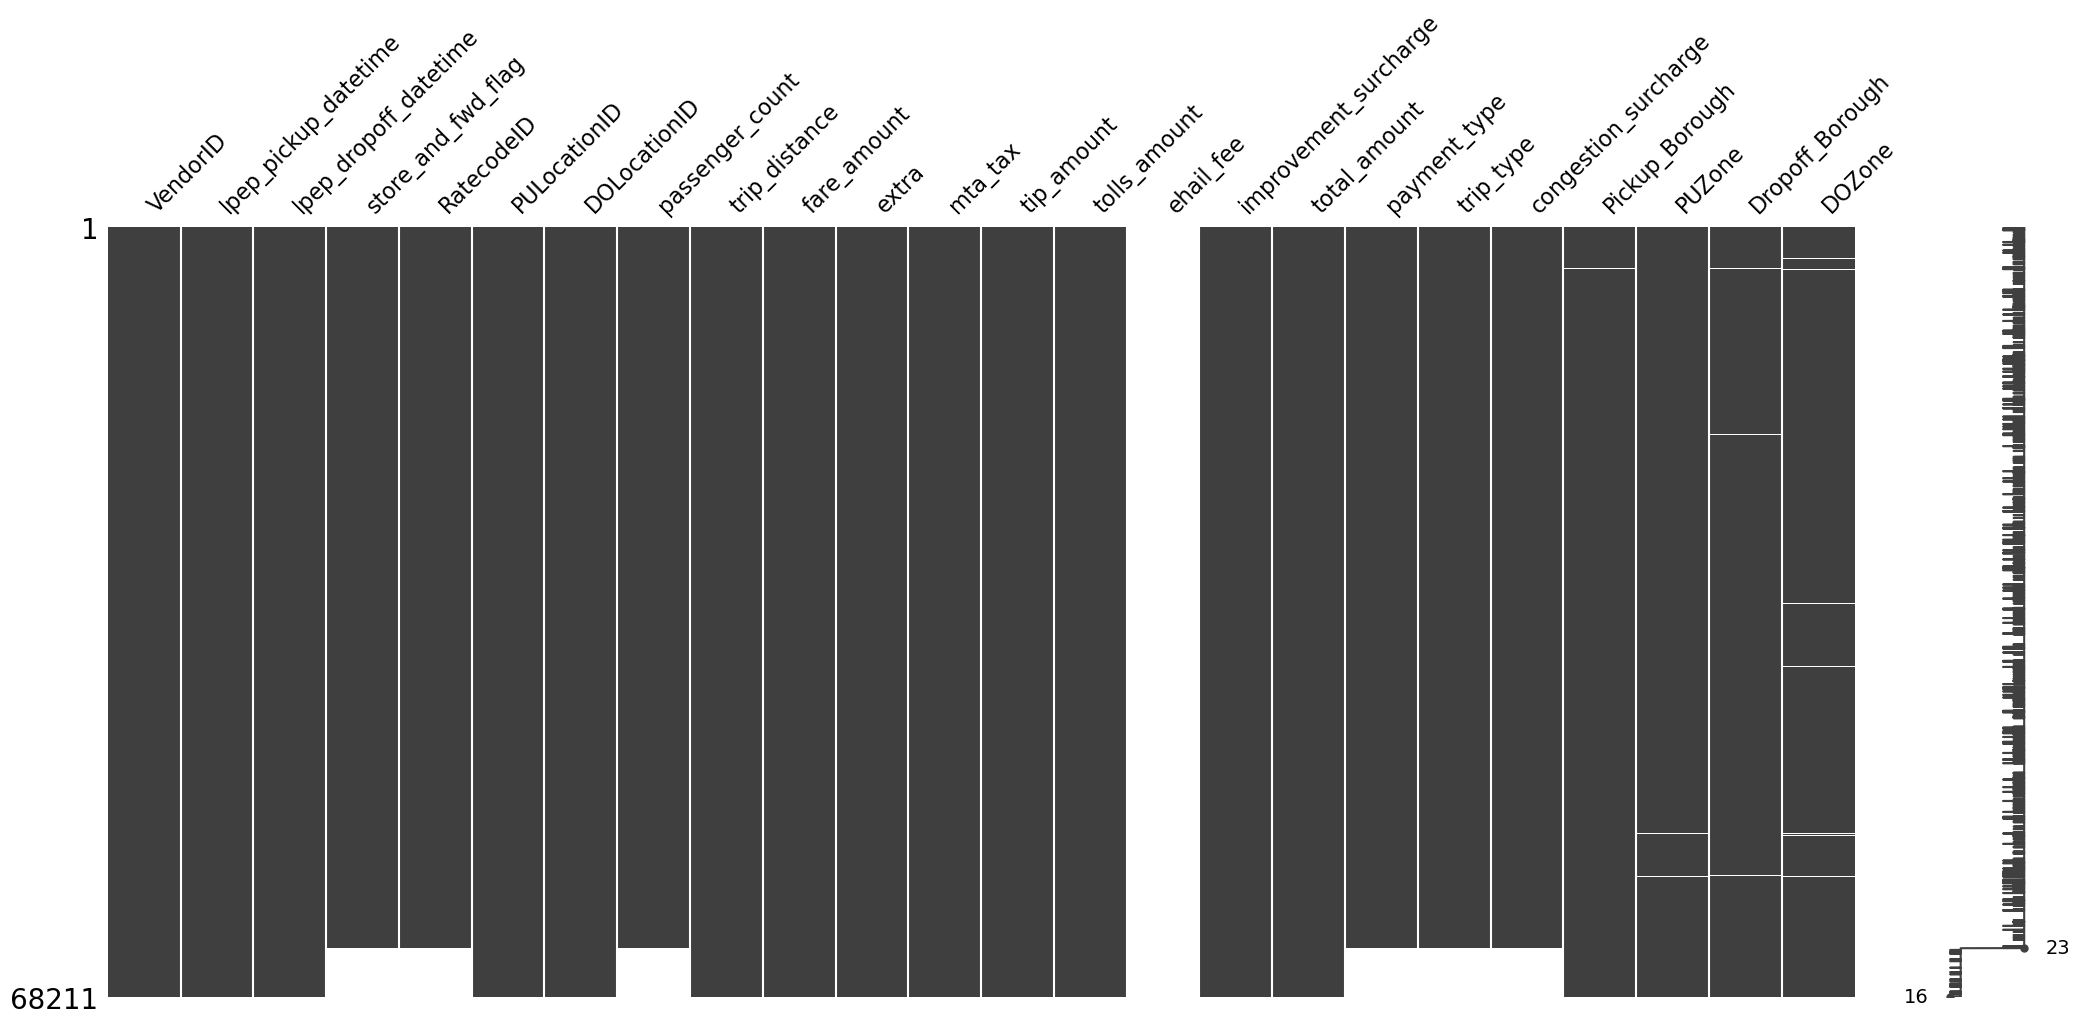

In [27]:
msno.matrix(df)
plt.show()

**Cek Proporsi Missing Values**

In [29]:
missing_percentage = (df.isna().sum() / df.shape[0]) * 100
print(missing_percentage.round(2).astype(str) + '%')

VendorID                   0.0%
lpep_pickup_datetime       0.0%
lpep_dropoff_datetime      0.0%
store_and_fwd_flag        6.34%
RatecodeID                6.34%
PULocationID               0.0%
DOLocationID               0.0%
passenger_count           6.34%
trip_distance              0.0%
fare_amount                0.0%
extra                      0.0%
mta_tax                    0.0%
tip_amount                 0.0%
tolls_amount               0.0%
ehail_fee                100.0%
improvement_surcharge      0.0%
total_amount               0.0%
payment_type              6.34%
trip_type                 6.35%
congestion_surcharge      6.34%
Pickup_Borough             0.1%
PUZone                     0.2%
Dropoff_Borough           0.35%
DOZone                    0.62%
dtype: object


## Menangani Missing Values

In [31]:
df.drop("ehail_fee", axis = 1,inplace=True)

> Karena kolom `ehail_fee` berisi 100% missing value, maka saya menghapus kolom karena tidak relevan dengan analisa data yang akan dilakukan.

In [33]:
df.dropna(inplace=True)

> Karena persentase missing values pada sebagian besar kolom masih relatif rendah, dan banyak kolom yang memiliki proporsi missing values yang serupa, kita dapat menganggap bahwa ini mengacu pada baris yang sama. Oleh karena itu, saya menghapus baris yang mengandung missing values.

In [35]:
df = df[(df['Pickup_Borough']!='Unknown')&(df['Dropoff_Borough']!='Unknown')]
df = df.dropna(subset=['Pickup_Borough', 'Dropoff_Borough'])

Pada kolom Pickup_Borough dan Dropoff_Borough, terdapat nilai unik 'Unknown' yang bisa diasumsikan setara dengan missing values karena tidak memberikan informasi yang relevan untuk analisis. Oleh karena itu, saya menghapus baris yang memiliki nilai tersebut.

In [37]:
df = df.dropna(subset=['PUZone','DOZone']).reset_index(drop=True)

> Pada kolom `PUZone` dan `DOZone` saya akan menghapus baris berisi missing values.

In [39]:
df.isna().sum()

VendorID                 0
lpep_pickup_datetime     0
lpep_dropoff_datetime    0
store_and_fwd_flag       0
RatecodeID               0
PULocationID             0
DOLocationID             0
passenger_count          0
trip_distance            0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
payment_type             0
trip_type                0
congestion_surcharge     0
Pickup_Borough           0
PUZone                   0
Dropoff_Borough          0
DOZone                   0
dtype: int64

> Data sudah tidak mengandung missing values.

# Data Cleaning

### Menangani Anomali

**`RateCodeID`**

Pada kolom `RateCodeID` terdapat nilai 99.0 sejumlah 10 yang tidak sesuai deskripsi, ini dapat kita drop saja.

In [44]:
df.drop(df[df['RatecodeID'] == 99.0].index, inplace=True)

**Nilai Negatif**

Pada kolom-kolom yang terkait dengan pembayaran, terlihat adanya banyak nilai negatif. Nilai negatif ini merupakan anomali karena tidak memiliki makna yang jelas. Oleh karena itu, kita dapat mengubah nilai negatif menjadi positif dengan asumsi bahwa hal tersebut disebabkan oleh kesalahan input.

In [46]:
fare_related_columns = [
    'fare_amount', 
    'extra', 
    'mta_tax', 
    'tip_amount', 
    'improvement_surcharge', 
    'total_amount', 
    'tolls_amount', 
    'congestion_surcharge'
]

df[fare_related_columns] = df[fare_related_columns].applymap(abs)

**Nilai 0**

Pada kolom passenger_count, terdapat nilai minimum 0 yang bisa dianggap sebagai anomali, karena dalam konteks dataset ini, jumlah penumpang tidak mungkin 0. Oleh karena itu, saya mengganti nilai 0 dengan modus dari nilai pada kolom passenger_count yang tidak bernilai 0.

In [48]:
df[df['passenger_count']==0]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,Pickup_Borough,PUZone,Dropoff_Borough,DOZone
98,2,2023-01-01 01:27:36,2023-01-01 01:27:43,N,5.0,168,168,0.0,0.0,20.0,...,0.0,1.0,21.00,1.0,2.0,0.00,Bronx,Mott Haven/Port Morris,Bronx,Mott Haven/Port Morris
247,1,2023-01-01 04:21:35,2023-01-01 04:30:00,N,1.0,129,129,0.0,1.3,8.0,...,4.0,1.0,16.80,1.0,1.0,0.00,Queens,Jackson Heights,Queens,Jackson Heights
435,1,2023-01-01 11:42:13,2023-01-01 11:49:21,N,1.0,260,260,0.0,1.2,8.6,...,0.0,1.0,12.10,1.0,1.0,0.00,Queens,Woodside,Queens,Woodside
474,1,2023-01-01 12:11:05,2023-01-01 12:20:45,N,1.0,42,127,0.0,3.4,16.3,...,0.0,1.0,18.80,1.0,1.0,0.00,Manhattan,Central Harlem North,Manhattan,Inwood
475,1,2023-01-01 12:56:11,2023-01-01 13:01:06,N,1.0,75,236,0.0,1.2,7.2,...,0.0,1.0,14.85,1.0,1.0,2.75,Manhattan,East Harlem South,Manhattan,Upper East Side North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62543,1,2023-01-31 18:27:02,2023-01-31 18:27:08,N,1.0,145,145,0.0,0.0,3.0,...,0.0,1.0,7.00,2.0,1.0,0.00,Queens,Long Island City/Hunters Point,Queens,Long Island City/Hunters Point
62551,1,2023-01-31 18:01:21,2023-01-31 18:09:22,N,1.0,236,236,0.0,1.0,9.3,...,0.0,1.0,19.25,1.0,1.0,2.75,Manhattan,Upper East Side North,Manhattan,Upper East Side North
62592,1,2023-01-31 18:07:39,2023-01-31 18:07:55,N,1.0,260,260,0.0,0.1,3.0,...,0.0,1.0,7.00,2.0,1.0,0.00,Queens,Woodside,Queens,Woodside
62724,1,2023-01-31 18:32:09,2023-01-31 18:32:33,N,1.0,145,145,0.0,0.0,3.0,...,0.0,1.0,7.00,3.0,1.0,0.00,Queens,Long Island City/Hunters Point,Queens,Long Island City/Hunters Point


> Terdapat 322 baris yang mengandung nilai 0 pada kolom `passenger_count`.

In [50]:
df.loc[df['passenger_count'] == 0, 'passenger_count'] = df.loc[df['passenger_count'] != 0, 'passenger_count'].mode()[0]

**trip_distance**

Pada kolom trip_distance, terdapat nilai 0 yang dapat diasumsikan sebagai kondisi di mana kendaraan tidak bergerak atau terjadi kesalahan pada pengukuran argo. Nilai 0 ini dapat dianggap sebagai anomali, karena dalam konteks dataset ini, jarak tidak mungkin 0. Oleh karena itu, saya menghapus baris yang memiliki nilai 0.

In [52]:
df = df[df['trip_distance'] != 0]

**fare_amount**

Menurut NYC.gov, nilai awal `fare_amount` adalah \$3.0.
Ini berarti untuk `fare_amount` yang bernilai di bawah \$3.0 merupakan anomali dan perlu ditangani.

Sumber: [Sumber Fare Amount](https://www.nyc.gov/site/tlc/passengers/taxi-fare.page)

In [55]:
fa_low = df[df['fare_amount']<0.3]
row_num = df.shape[0]

prop_fa_low = fa_low.shape[0]
perc_fa_low = (prop_fa_low / row_num) * 100
print(f'Proporsi anomali pada kolom trip_distance terhadap keseluruhan data: {perc_fa_low:.2f}%')

Proporsi anomali pada kolom trip_distance terhadap keseluruhan data: 0.04%


In [56]:
df.drop(df[df['fare_amount'] < 0.3].index, inplace=True)

**lpep_pickup_datetime & lpep_dropoff_datetime**

Pada kolom `lpep_pickup_datetime` dan `lpep_dropoff_datetime`, terdapat satu data di tahun 2009, dan dua data di tahun 2022.
Data ini dapat di drop agar kita dapat fokus menganalisa data dalam waktu yang berdekatan.

In [58]:
# Menghapus data yang tahunnya 2009 dan 2022
df = df[~df['lpep_pickup_datetime'].dt.year.isin([2009, 2022])].reset_index(drop=True)
df = df[~df['lpep_dropoff_datetime'].dt.year.isin([2009, 2022])].reset_index(drop=True)

**improvement_surcharge**

Menurut website NYC.gov, `improvement_surcharge` merupakan tarif tetap sebesar \\$1. Oleh karena itu, saya akan mengganti nilai improvement_surcharge yang tidak sebesar \\$1 agar sesuai dengan informasi yang telah diperoleh.

Sumber: [Sumber Improvement Surcharge](https://www.nyc.gov/site/tlc/passengers/taxi-fare.page)

In [60]:
df.loc[df['improvement_surcharge'] != 1.0, 'improvement_surcharge'] = 1.0

**total_amount**

Kolom `total_amount` merupakan total yang akan dibayarkan oleh penumpang, kita perlu melihat apakah sudah sesuai dengan jumlah dari kolom lain yang berkaitan dengan pembayaran.

In [62]:
# Kalkulasi total_amount yang benar
df['calculated_total'] = (df['fare_amount'] + 
                          df['extra'] + 
                          df['mta_tax'] + 
                          df['tip_amount'] + 
                          df['improvement_surcharge'] + 
                          df['tolls_amount'] + 
                          df['congestion_surcharge'])

# Melihat baris yang sudah sesuai
df['total_matches'] = df['calculated_total'] == df['total_amount']

# Filter baris yang belum sesuai
mismatched_rows = df[~df['total_matches']]

# Cek proportsi
mismatched_proportion = (len(mismatched_rows) / len(df)) * 100
print(f"Proporsi baris yang belum sesuai: {mismatched_proportion:.2f}%")

Proporsi baris yang belum sesuai: 26.15%


In [63]:
# Impute nilai yang benar ke kolom total_amount yang belum sesuai
df.loc[~df['total_matches'], 'total_amount'] = df.loc[~df['total_matches'], 'calculated_total']

# Drop kolom yang tidak digunakan
df = df.drop(columns=['calculated_total', 'total_matches'])

**trip_duration**

Sekarang saya menambahkan kolom `trip_duration` dan `trip_duration_hour` sebagai filter apabila durasi sama dengan 0, atau argo tidak merekam maka data akan dihapus.

In [65]:
# Menghitung durasi perjalanan
df['trip_duration'] = df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']

# Mengonversi durasi ke dalam satuan jam
df['trip_duration_hour'] = round(df['trip_duration'].dt.total_seconds() / 3600, 2)

# Filter perjalanan dengan durasi positif
df = df[df['trip_duration_hour'] >= 0]

### Menghandle Extreme Outliers

**tip_amount**

<Axes: xlabel='tip_amount'>

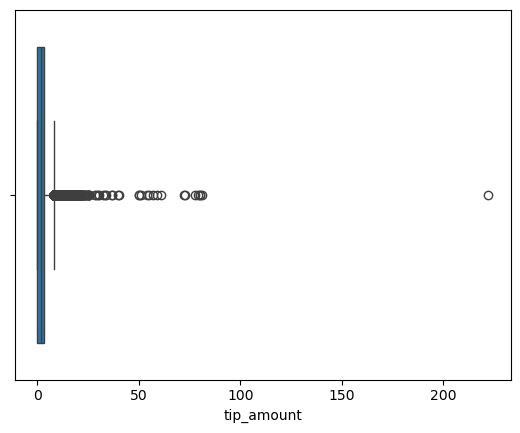

In [68]:
sns.boxplot(df['tip_amount'], orient='h')

> Dari boxplot di atas, kita dapat mengidentifikasi adanya outliers ekstrem dengan nilai di atas $200. Nilai ini dapat dianggap sebagai kesalahan input, sehingga saya akan menghapus data tersebut.

In [70]:
df = df[df['tip_amount']<100]

**Melihat Korelasi Kolom `trip_distance` dan `fare_amount`**

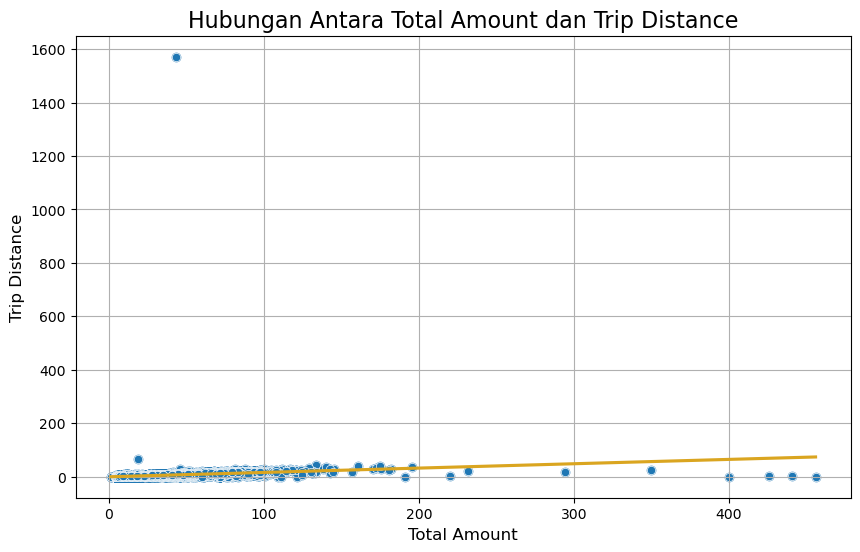

In [72]:
plt.figure(figsize=(10, 6))
sns.regplot(x='total_amount', y='trip_distance', data=df, line_kws={'color': 'goldenrod'}, ci=False)
sns.scatterplot(x='total_amount', y='trip_distance', data=df)
plt.title('Hubungan Antara Total Amount dan Trip Distance', fontsize=16)
plt.xlabel('Total Amount', fontsize=12)
plt.ylabel('Trip Distance', fontsize=12)
plt.grid(True)
plt.show()

> Dari Scatterplot kita dapat melihat *contextual outliers* pada kolom `trip_distance`, saya akan impute nilai dengan central tendency dari data. Untuk mengetahui central tendency yang baiknya dipakai, mari uji normalitas distribusi data terlebih dahulu:

In [74]:
ks_test = kstest(df['trip_distance'], 'norm')

print(f'Kolmogorov-Smirnov Test: D={ks_test[0]}, p-value={ks_test[1]}')

alpha = 0.05
if ks_test[1] < alpha:
    print("Menolak H0: Data tidak terdistribusi normal.")
else:
    print("Gagal menolak H0: Data terdistribusi normal.")


Kolmogorov-Smirnov Test: D=0.6858053716548368, p-value=0.0
Menolak H0: Data tidak terdistribusi normal.


In [75]:
median_trip_distance = df[df['trip_distance'] <= 120]['trip_distance'].median()
df.loc[df['trip_distance'] > 120, 'trip_distance'] = median_trip_distance

Tidak ada batasan jarak tempuh taksi di New York City, namun kita dapat mengasumsikan untuk perjalanan yang hanya menempuh jarak 0.5 mil dapat dikategorikan tidak biasa dan dapat kita drop.

Sumber: [Sumber Trip Distance Lower](https://www.researchgate.net/figure/Trip-Length-and-Time-of-Day-Histograms-of-All-Taxi-Trips-and-the-Three-Categories_fig3_317754393)


Sedangkan untuk perjalanan yang lebih dari 120 mil dianggap sebagai extreme outliers dan dapat kita impute dengan measure of central tendency berupa median karena data pada kolom `trip_distance` tidak terdistribusi normal.

Sumber: [Sumber Trip Distance Upper](https://medium.com/@muhammadaris10/nyc-taxi-trip-data-analysis-45ecfdcb6f91#:~:text=Various%20techniques%20were%20also%20implemented,location%20points%20within%20the%20dataset.) 

**duration_hrs**

Saya menambahkan kolom untuk cek durasi setiap perjalanan dalam satuan jam, guna melihat apakah ada data anomali.

In [78]:
df['duration_hrs'] = (df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']).dt.total_seconds() / 3600

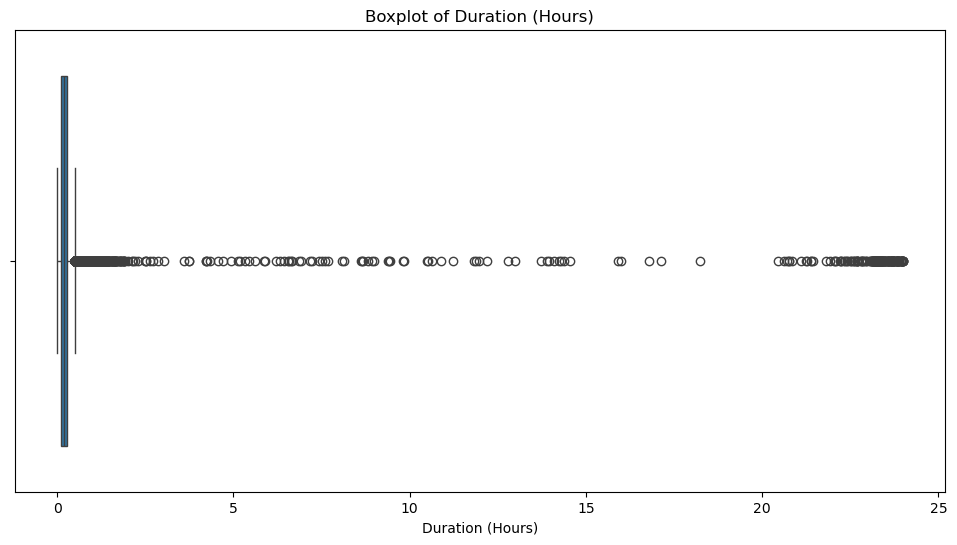

In [79]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['duration_hrs'])
plt.title('Boxplot of Duration (Hours)')
plt.xlabel('Duration (Hours)')
plt.show()

In [80]:
df = df[(df['duration_hrs']<12) & (df['duration_hrs']!=0)]

> Dari sebaran durasi kita dapat melihat terdapat nilai yang mencapai 24 jam, hal ini merupakan anomali. Menurut NYC.gov, durasi maksimum yang diizinkan untuk perjalanan taksi Kota New York adalah 12 jam.
>
> Maka dari itu, saya menghapus data yang memiliki durasi di atas 12 jam dan durasi 0.
>
> Sumber: [Sumber Durasi](https://www.nyc.gov/site/tlc/passengers/passenger-frequently-asked-questions.page#:~:text=If%20the%20trip%20would%20result,Refusal%20Law)

**speed(mph)**

Saya menambahkan kolom `speed(mph)` untuk membantu memahami data dengan melihat kecepatan pada tiap perjalanan, kita juga dapat melihat anomali apabila terdapat perjalanan dengan kecepatan yang tidak masuk akal.

In [83]:
df['speed(mph)'] = round(df['trip_distance'] / df['duration_hrs'], 2)

Berdasarkan data dari Komisi Taksi dan Limusin Kota New York (TLC), kecepatan taksi rata-rata sering ditemukan berkisar antara 10 hingga 14 mph. Namun, kecepatan ini dapat bervariasi tergantung pada kepadatan lalu lintas, dengan kemungkinan kecepatan yang lebih rendah karena potensi kemacetan lalu lintas, yang menetapkan toleransi kecepatan minimum lebih dari 5 mph.

Kecepatan lalu lintas rata-rata di pusat kota turun hingga 3,2 mph.

Sumber : [Kecepatan Macet](https://www.axios.com/2024/09/23/new-york-congestion)
 
Di New York City sendiri, kecepatan maksimum di dalam kota adalah 25 mph, sedangkan di jalan raya, kecepatannya sekitar 65 mph. Dengan toleransi 5 mph, toleransi kecepatan tertinggi adalah 70 mph.

Sumber: [Sumber Kecepatan Taxi](https://medium.com/@muhammadaris10/nyc-taxi-trip-data-analysis-45ecfdcb6f91#:~:text=Various%20techniques%20were%20also%20implemented,location%20points%20within%20the%20dataset.)

Berdasarkan informasi tersebut saya akan menghapus data dengan kecepatan yang tidak sesuai.

In [85]:
df = df[(df['speed(mph)'] < 70) & (df['speed(mph)'] != 0)]

**Cek Data Duplikat**

In [87]:
df.duplicated().sum()

99

In [88]:
df = df.drop_duplicates()

> Pada data masih terdapat baris duplikat, sehingga saya menghapus baris tersebut.

**Drop Kolom Redundant**

In [91]:
df = df.drop(columns=['trip_duration_hour'])

**Data Bersih**

In [93]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,payment_type,trip_type,congestion_surcharge,Pickup_Borough,PUZone,Dropoff_Borough,DOZone,trip_duration,duration_hrs,speed(mph)
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0,166,143,1.0,2.58,14.9,...,1.0,1.0,2.75,Manhattan,Morningside Heights,Manhattan,Lincoln Square West,0 days 00:11:01,0.183611,14.05
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0,24,43,1.0,1.81,10.7,...,1.0,1.0,0.00,Manhattan,Bloomingdale,Manhattan,Central Park,0 days 00:06:46,0.112778,16.05
2,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0,41,238,1.0,1.30,6.5,...,1.0,1.0,0.00,Manhattan,Central Harlem,Manhattan,Upper West Side North,0 days 00:05:49,0.096944,13.41
3,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0,41,74,1.0,1.10,6.0,...,1.0,1.0,0.00,Manhattan,Central Harlem,Manhattan,East Harlem North,0 days 00:05:58,0.099444,11.06
4,2,2023-01-01 00:53:31,2023-01-01 01:11:04,N,1.0,41,262,1.0,2.78,17.7,...,2.0,1.0,2.75,Manhattan,Central Harlem,Manhattan,Yorkville East,0 days 00:17:33,0.292500,9.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60315,2,2023-01-31 23:09:22,2023-01-31 23:17:21,N,5.0,130,205,1.0,2.75,15.0,...,1.0,2.0,0.00,Queens,Jamaica,Queens,Saint Albans,0 days 00:07:59,0.133056,20.67
60316,2,2023-01-31 23:06:18,2023-01-31 23:17:03,N,1.0,65,181,1.0,2.44,13.5,...,1.0,1.0,0.00,Brooklyn,Downtown Brooklyn/MetroTech,Brooklyn,Park Slope,0 days 00:10:45,0.179167,13.62
60317,2,2023-01-31 23:17:03,2023-01-31 23:23:04,N,1.0,244,116,1.0,1.40,9.3,...,1.0,1.0,0.00,Manhattan,Washington Heights South,Manhattan,Hamilton Heights,0 days 00:06:01,0.100278,13.96
60318,2,2023-01-31 23:29:18,2023-01-31 23:38:50,N,1.0,74,238,1.0,2.47,13.5,...,1.0,1.0,2.75,Manhattan,East Harlem North,Manhattan,Upper West Side North,0 days 00:09:32,0.158889,15.55


In [94]:
df.to_csv('df_bersih.csv', index=False)

> Data sudah bersih, kini kita dapat lanjut melakukan analisa.

# Exploratory Data Analysis (EDA)

In [97]:
print(f'''
Jumlah baris pada dataset: {df.shape[0]}
Jumlah kolom pada dataset: {df.shape[1]}
''')


Jumlah baris pada dataset: 59898
Jumlah kolom pada dataset: 26



In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59898 entries, 0 to 60319
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype          
---  ------                 --------------  -----          
 0   VendorID               59898 non-null  object         
 1   lpep_pickup_datetime   59898 non-null  datetime64[ns] 
 2   lpep_dropoff_datetime  59898 non-null  datetime64[ns] 
 3   store_and_fwd_flag     59898 non-null  object         
 4   RatecodeID             59898 non-null  object         
 5   PULocationID           59898 non-null  object         
 6   DOLocationID           59898 non-null  object         
 7   passenger_count        59898 non-null  float64        
 8   trip_distance          59898 non-null  float64        
 9   fare_amount            59898 non-null  float64        
 10  extra                  59898 non-null  float64        
 11  mta_tax                59898 non-null  float64        
 12  tip_amount             59898 non-null  float64     

## Statistik Deskriptif

In [100]:
print('\nStatistik Deskriptif Kolom Numerikal:')
exclude_columns = ['lpep_pickup_datetime', 'lpep_dropoff_datetime', 'trip_duration']
display(df.drop(columns=exclude_columns).describe())

print('\nDeskripsi Kolom Non-numerikal:')
display(df.describe(include='object'))


Statistik Deskriptif Kolom Numerikal:


,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration_hrs,speed(mph)
count,59898.000000,59898.000000,59898.000000,59898.000000,59898.000000,59898.000000,59898.000000,59898.0,59898.000000,59898.000000,59898.000000,59898.000000
mean,1.330913,2.647984,15.723014,0.918620,0.619069,2.098561,0.125537,1.0,21.249618,0.764817,0.227539,11.737548
std,0.990531,2.500778,11.225411,1.304795,0.338590,2.784426,0.928319,0.0,13.354235,1.232136,0.272784,5.236392
min,1.000000,0.010000,0.300000,0.000000,0.000000,0.000000,0.000000,1.0,1.300000,0.000000,0.000556,0.010000
25%,1.000000,1.200000,9.300000,0.000000,0.500000,0.000000,0.000000,1.0,12.900000,0.000000,0.121111,8.490000
50%,1.000000,1.880000,12.800000,0.000000,0.500000,1.660000,0.000000,1.0,17.700000,0.000000,0.185556,10.560000
75%,1.000000,3.140000,18.400000,2.500000,0.500000,3.280000,0.000000,1.0,25.600000,2.750000,0.276944,13.530000
max,7.000000,66.180000,455.000000,7.500000,1.500000,80.880000,36.050000,1.0,456.000000,2.750000,11.978611,65.450000



Deskripsi Kolom Non-numerikal:


,VendorID,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,payment_type,trip_type,Pickup_Borough,PUZone,Dropoff_Borough,DOZone
count,59898,59898,59898.0,59898,59898,59898.0,59898.0,59898,59898,59898,59898
unique,2,2,5.0,181,242,4.0,2.0,5,180,6,241
top,2,N,1.0,74,75,1.0,1.0,Manhattan,East Harlem North,Manhattan,East Harlem South
freq,52314,59656,58953.0,12639,3300,38078.0,59204.0,36511,12639,36425,3300


## Visualisasi Data

**Melihat Jumlah Data Pada Kolom Kategorikal**

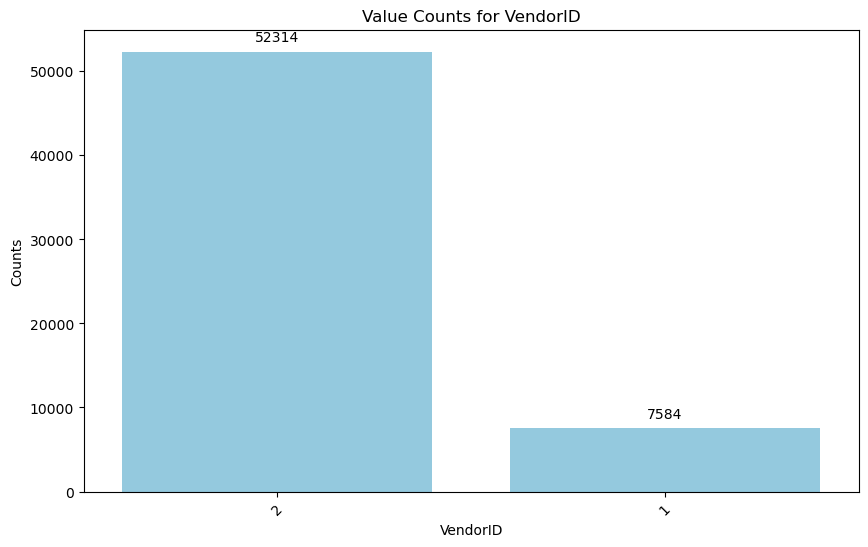

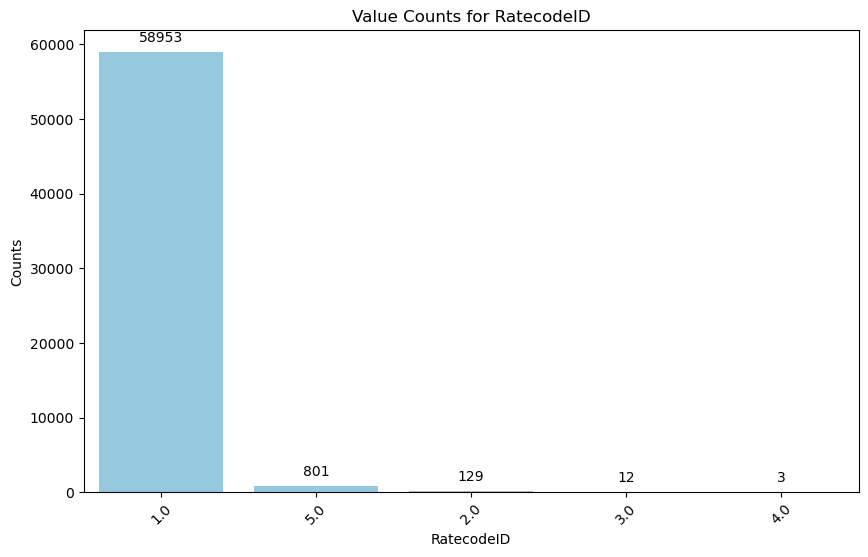

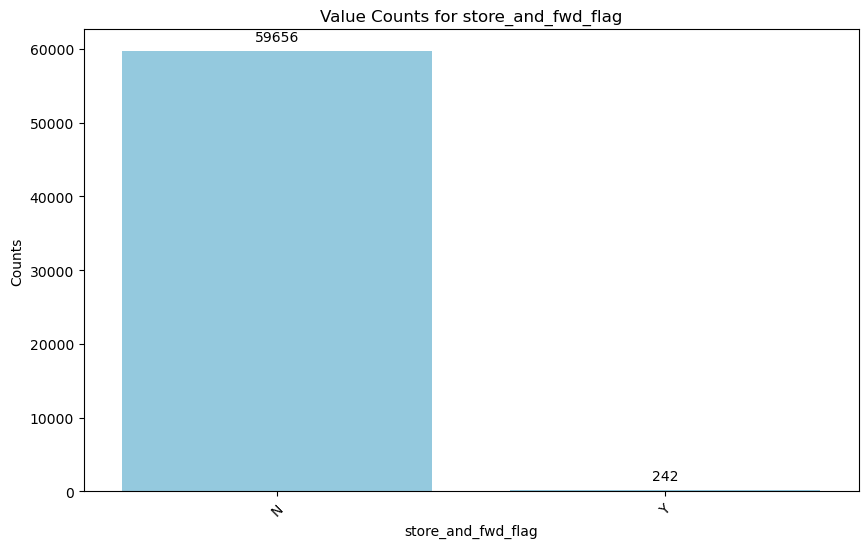

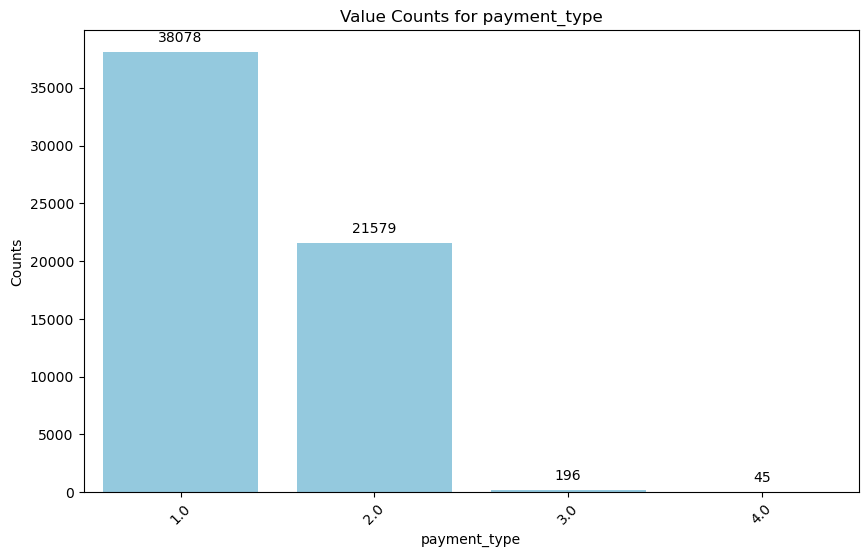

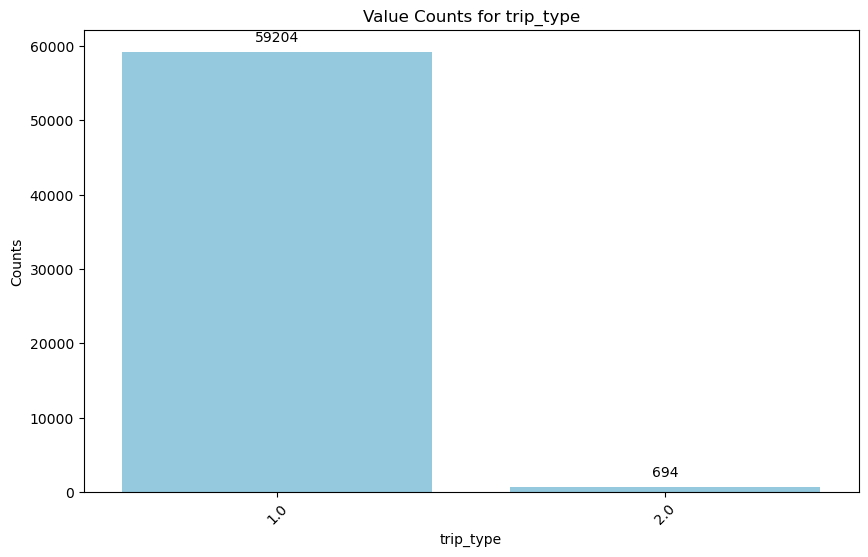

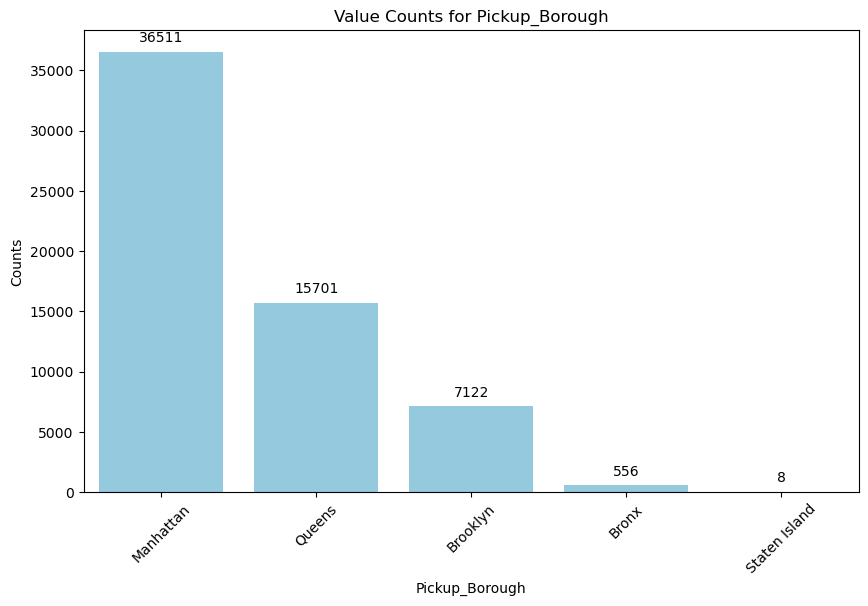

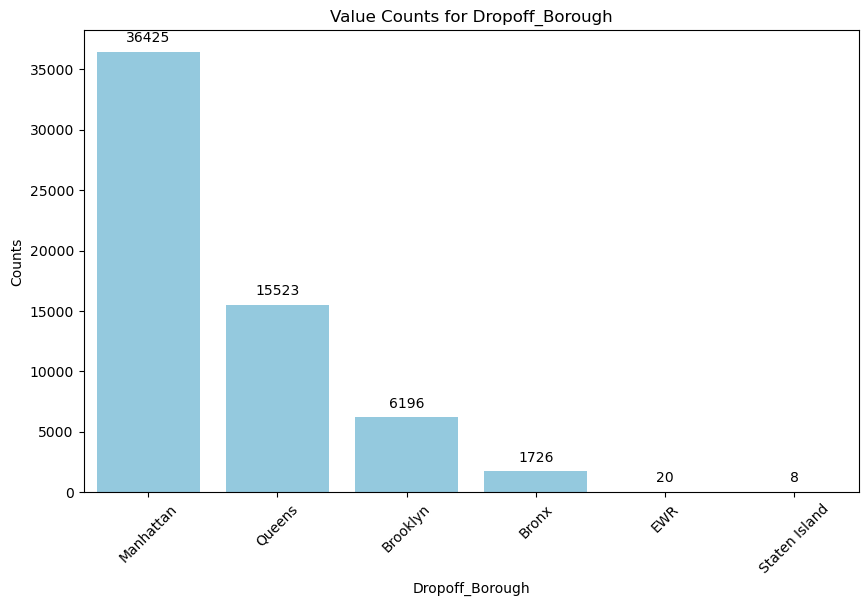

In [103]:
categories = ['VendorID', 
              'RatecodeID',
              'store_and_fwd_flag', 
              'payment_type', 
              'trip_type', 
              'Pickup_Borough', 
              'Dropoff_Borough']

# Membuat barplot
for col in categories:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df, x=col, color='skyblue', order=df[col].value_counts().index)
    plt.title(f'Value Counts for {col}')
    plt.xticks(rotation=45)
    plt.ylabel('Counts')
    plt.xlabel(col)

    # Menambahkan anotasi
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{round(height)}', 
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 5), 
                    textcoords='offset points', 
                    ha='center', 
                    va='bottom', 
                    fontsize=10)
    
    plt.show()

**Melihat Persebaran Data Pada Kolom Numerikal**

<Axes: >

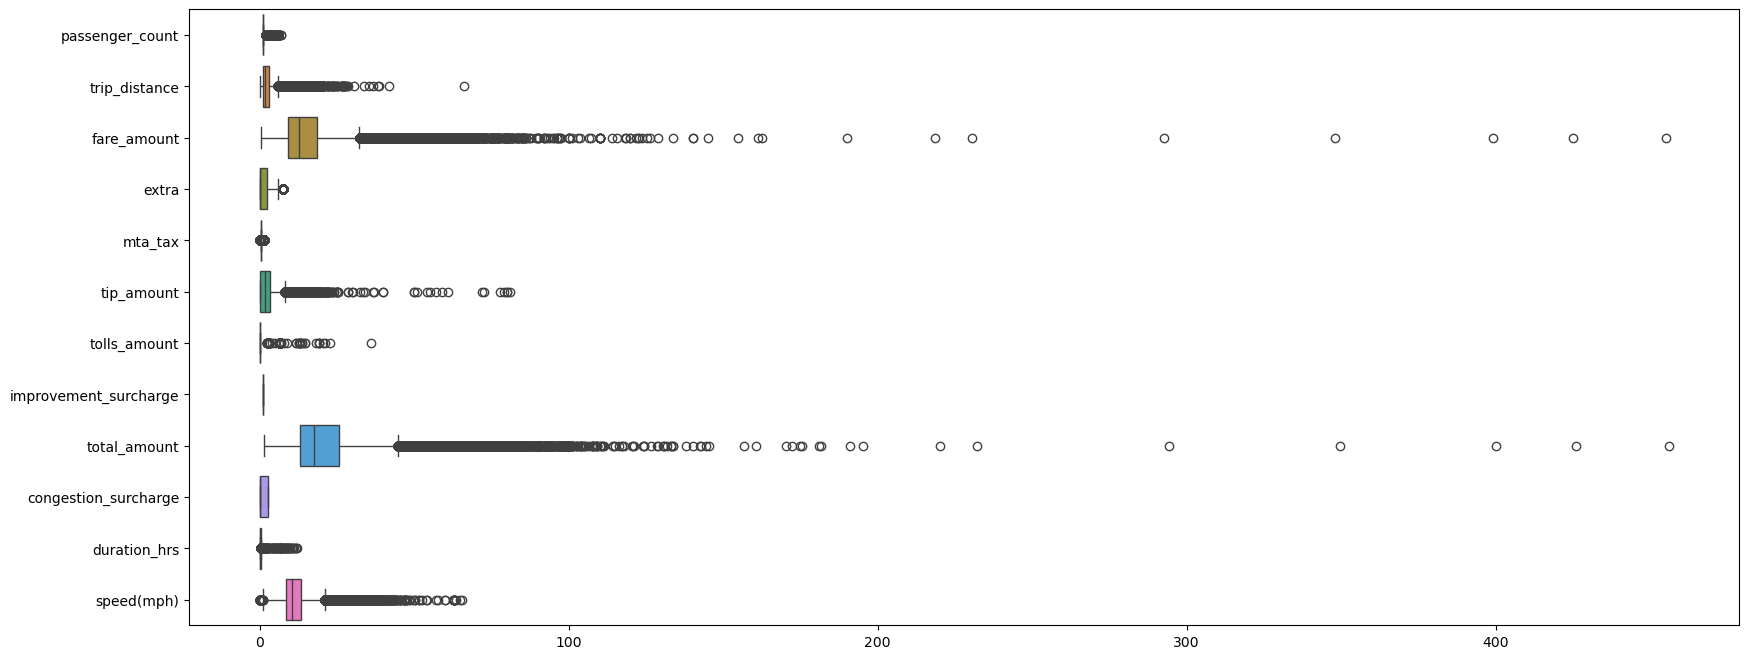

In [105]:
df_no_lat_long = df.drop(columns=['lpep_pickup_datetime', 'lpep_dropoff_datetime', 'trip_duration'])
numerical_df = df_no_lat_long.select_dtypes(include='number')

plt.figure(figsize=(20,8))
sns.boxplot(data=numerical_df, orient='h')

**Melihat Korelasi Kolom `trip_distance` dan `total_amount`**

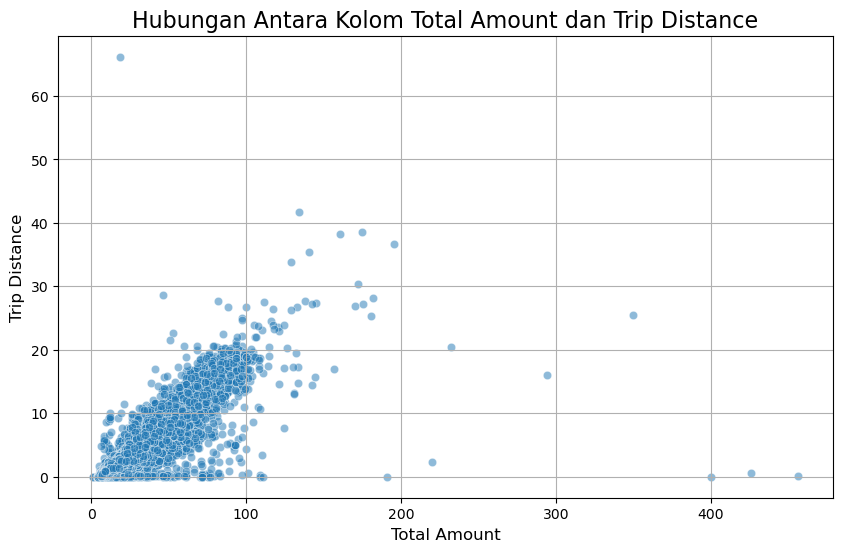

In [107]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_amount', y='trip_distance', data=df, alpha=0.5)
plt.title('Hubungan Antara Kolom Total Amount dan Trip Distance', fontsize=16)
plt.xlabel('Total Amount', fontsize=12)
plt.ylabel('Trip Distance', fontsize=12)
plt.grid(True)
plt.show()

> Grafik di atas memberikan gambaran visual mengenai hubungan antara total biaya perjalanan (Total Amount) dengan jarak tempuh perjalanan (Trip Distance).
>
> Insight:
> - Tren pada jarak tempuh cenderung meningkat seiring dengan peningkatan total biaya. Ini menunjukkan adanya korelasi positif yang kuat antara kedua variabel. Artinya, semakin jauh jarak tempuh perjalanan, maka semakin besar pula total biayanya.
> - Meskipun terdapat tren positif yang jelas, data juga menunjukkan adanya variasi yang cukup besar. Artinya, tidak semua perjalanan dengan jarak tempuh yang sama memiliki biaya yang sama persis.

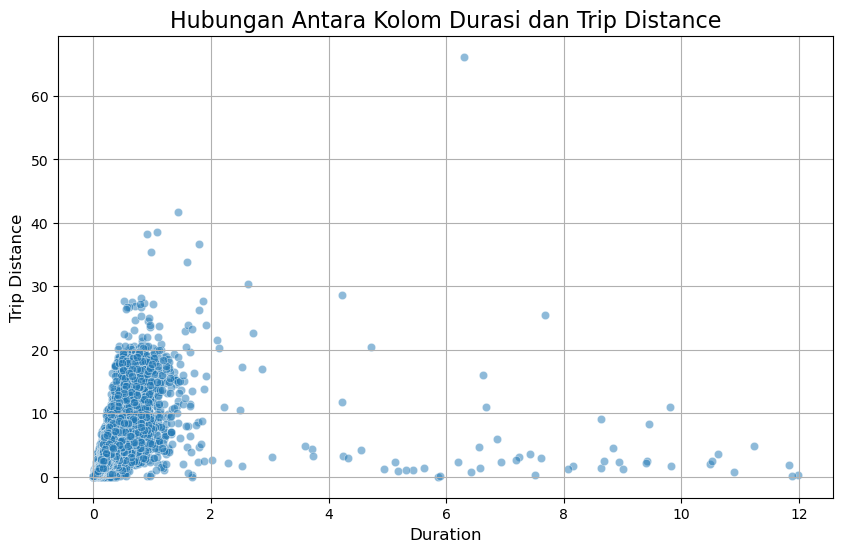

In [109]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_hrs', y='trip_distance', data=df, alpha=0.5)
plt.title('Hubungan Antara Kolom Durasi dan Trip Distance', fontsize=16)
plt.xlabel('Duration', fontsize=12)
plt.ylabel('Trip Distance', fontsize=12)
plt.grid(True)
plt.show()

> Grafik di atas memberikan gambaran visual mengenai hubungan antara durasi perjalanan (Duration) dengan jarak tempuh perjalanan (Trip Distance).
>
> Insight:
> - Untuk persebaran data durasi terhadap jarak banyak terkumpul di rentang 0-2 jam dan jarak 0-30, sekilas terlihat korelasi yang positif di mana ketika durasi bertambah, jarak perjalanan juga bertambah.

## Correlation Heatmap

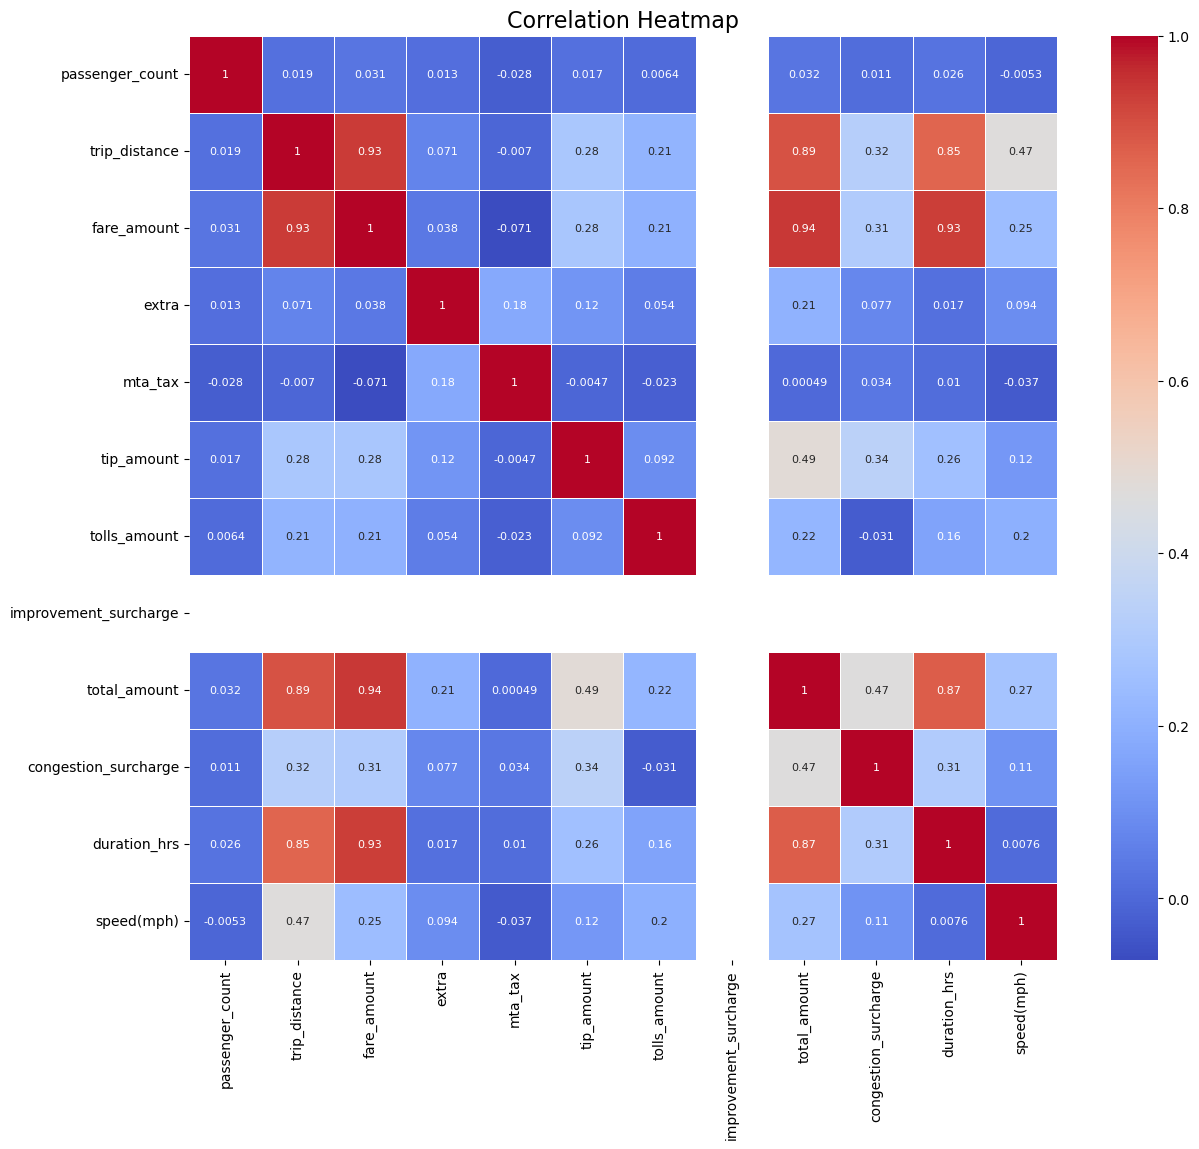

In [112]:
correlation_matrix = numerical_df.corr(method='spearman')

# Menghasilkan heatmap dengan ukuran yang lebih besar dan anotasi yang lebih kecil
plt.figure(figsize=(14, 12))  # Membesarkan ukuran heatmap
sns.heatmap(correlation_matrix, annot=True, annot_kws={"size": 8}, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# Analisa Data

## Identifikasi Pola Waktu Sibuk Pada Setiap Borough

In [115]:
# Filter kolom yang akan digunakan
df_analysis1 = df[['Pickup_Borough', 'Dropoff_Borough']]

df_analysis1['pickup_hour'] = df['lpep_pickup_datetime'].dt.hour
df_analysis1['dropoff_hour'] = df['lpep_dropoff_datetime'].dt.hour

df_analysis1['pickup_day'] = df['lpep_pickup_datetime'].dt.dayofweek  # 0 = Senin, 6 = Minggu
df_analysis1['dropoff_day'] = df['lpep_dropoff_datetime'].dt.dayofweek  # 0 = Senin, 6 = Minggu

df_analysis1['pickup_date'] = pd.to_datetime(df['lpep_pickup_datetime'].dt.date)
df_analysis1['dropoff_date'] = pd.to_datetime(df['lpep_dropoff_datetime'].dt.date)

df_analysis1

,Pickup_Borough,Dropoff_Borough,pickup_hour,dropoff_hour,pickup_day,dropoff_day,pickup_date,dropoff_date
0,Manhattan,Manhattan,0,0,6,6,2023-01-01,2023-01-01
1,Manhattan,Manhattan,0,0,6,6,2023-01-01,2023-01-01
2,Manhattan,Manhattan,0,0,6,6,2023-01-01,2023-01-01
3,Manhattan,Manhattan,0,0,6,6,2023-01-01,2023-01-01
4,Manhattan,Manhattan,0,1,6,6,2023-01-01,2023-01-01
...,...,...,...,...,...,...,...,...
60315,Queens,Queens,23,23,1,1,2023-01-31,2023-01-31
60316,Brooklyn,Brooklyn,23,23,1,1,2023-01-31,2023-01-31
60317,Manhattan,Manhattan,23,23,1,1,2023-01-31,2023-01-31
60318,Manhattan,Manhattan,23,23,1,1,2023-01-31,2023-01-31


In [116]:
# Fungsi untuk mengkonversi format 24-jam menjadi format 12-jam AM/PM
def convert_to_ampm(hour):
    if hour == 0:
        return '12 AM'
    elif hour < 12:
        return f'{hour} AM'
    elif hour == 12:
        return '12 PM'
    else:
        return f'{hour - 12} PM'

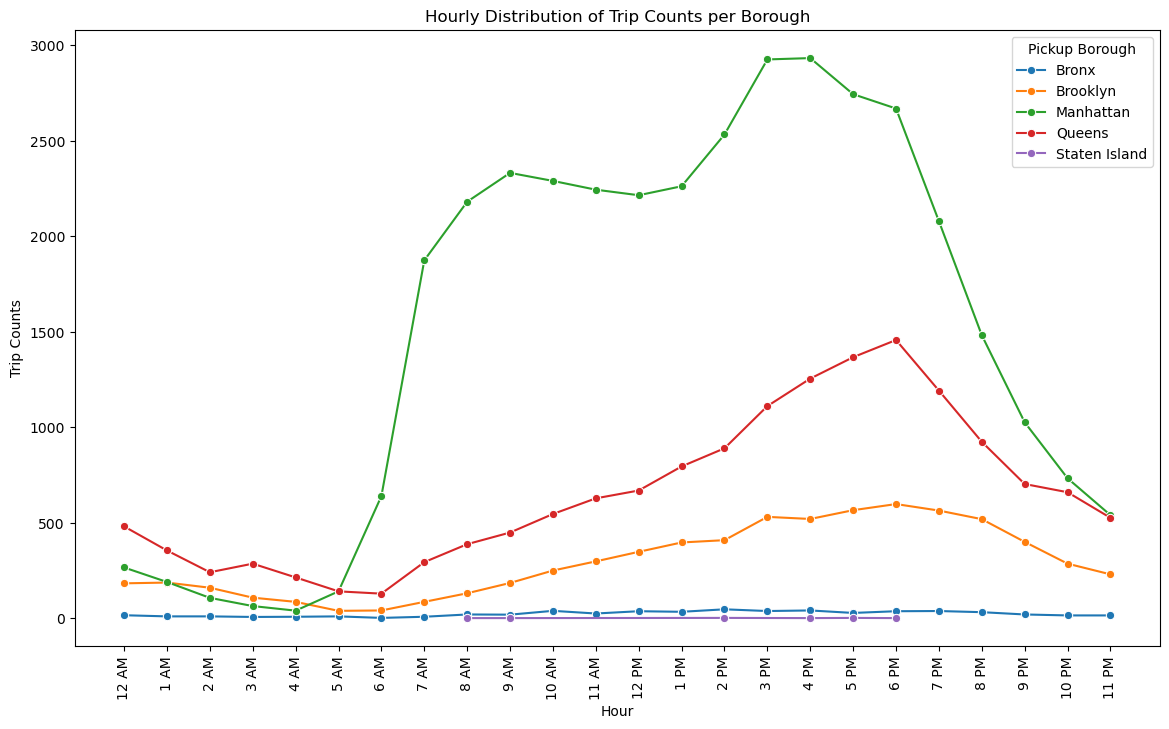

In [117]:
# Menghitung jumlah perjalanan tiap jam per Borough
hourly_counts = df_analysis1.groupby(['pickup_hour', 'Pickup_Borough']).size().reset_index(name='trip_counts')

# Menghasilkan lineplot
plt.figure(figsize=(14, 8))
sns.lineplot(x='pickup_hour', y='trip_counts', hue='Pickup_Borough', data=hourly_counts, marker='o')
plt.title('Hourly Distribution of Trip Counts per Borough')
plt.xlabel('Hour')
plt.ylabel('Trip Counts')
plt.xticks(ticks=range(0, 24), labels=[convert_to_ampm(hour) for hour in range(0, 24)], rotation=90)
plt.legend(title='Pickup Borough')
plt.show()

In [118]:
# Simpan data untuk Tableau
hourly_counts.to_csv('hourly_counts.csv', index=False)

> Lineplot di atas yang menunjukkan distribusi jumlah perjalanan per jam untuk setiap borough, berikut adalah beberapa **insight** yang dapat diambil:
>
> - Manhattan memiliki jumlah perjalanan tertinggi sepanjang hari, dapat dilihat bahwa kenaikan volume perjalanan pada jam 6-7 pagi lumayan signifikan. Ini menunjukkan tingginya volume perjalanan selama jam sibuk pagi hari, yang kemungkinan besar disebabkan oleh banyaknya penumpang yang menuju tempat kerja.
> - Pada borough Queens dan Brooklyn, terlihat tren peningkatan volume perjalanan yang dimulai sejak pukul 6 pagi. Hal ini kemungkinan disebabkan oleh aktivitas pagi hari, seperti orang-orang yang berangkat bekerja, sekolah, atau melakukan perjalanan lainnya, terutama karena kedua borough ini merupakan area dengan kepadatan penduduk yang tinggi dan banyaknya penduduk yang melakukan perjalanan ke Manhattan atau area lain di pagi hari.
> - Secara general, volume perjalanan di Staten Island dan Bronx tidak begitu banyak. Hal ini mungkin disebabkan oleh rendahnya jumlah perjalanan yang dilakukan dibandingkan dengan borough lainnya, karena keduanya memiliki populasi yang lebih sedikit, tingkat aktivitas ekonomi yang lebih rendah, atau keterbatasan akses transportasi. Selain itu, Staten Island cenderung lebih terisolasi secara geografis, dan Bronx memiliki pola perjalanan yang mungkin lebih konsisten sepanjang hari tanpa lonjakan tertentu.

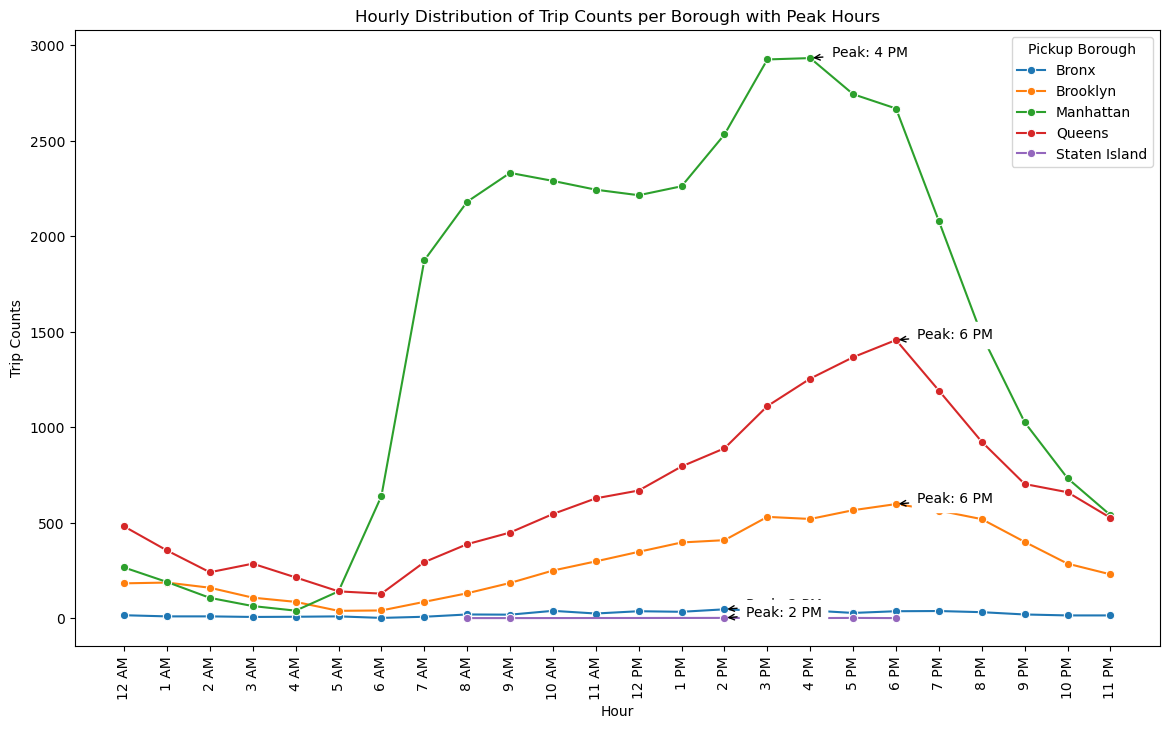

In [120]:
# Mencari peak hours untuk setiap borough
peak_hours = hourly_counts.loc[hourly_counts.groupby('Pickup_Borough')['trip_counts'].idxmax()]

# Menghasilkan lineplot dengan anotasi peak hours
plt.figure(figsize=(14, 8))
sns.lineplot(x='pickup_hour', y='trip_counts', hue='Pickup_Borough', data=hourly_counts, marker='o')

# Menambahkan anotasi untuk peak hours
for _, row in peak_hours.iterrows():
    peak_hour_ampm = convert_to_ampm(row['pickup_hour'])
    plt.annotate(f"Peak: {peak_hour_ampm}",
                 xy=(row['pickup_hour'], row['trip_counts']),
                 xytext=(row['pickup_hour'] + 0.5, row['trip_counts'] + 5),
                 arrowprops=dict(arrowstyle="->", color='black'),
                 backgroundcolor='white')

plt.title('Hourly Distribution of Trip Counts per Borough with Peak Hours')
plt.xlabel('Hour')
plt.ylabel('Trip Counts')
plt.legend(title='Pickup Borough')
plt.xticks(ticks=range(0, 24), labels=[convert_to_ampm(hour) for hour in range(0, 24)], rotation=90)
plt.show()

In [121]:
# Simpan data untuk Tableau
peak_hours.to_csv('peak_hours.csv', index=False)

> Lineplot di atas yang menunjukkan distribusi jumlah perjalanan per jam untuk setiap borough, berikut adalah beberapa **insight** yang dapat diambil:
>
> - Peak hour pada borough Manhattan adalah pada jam 4 sore.
> - Peak hour pada borough Brooklyn dan Queens adalah pada jam 6 sore.
> - Peak hour pada borough Staten Island dan Bronx adalah pada jam 2 sore.

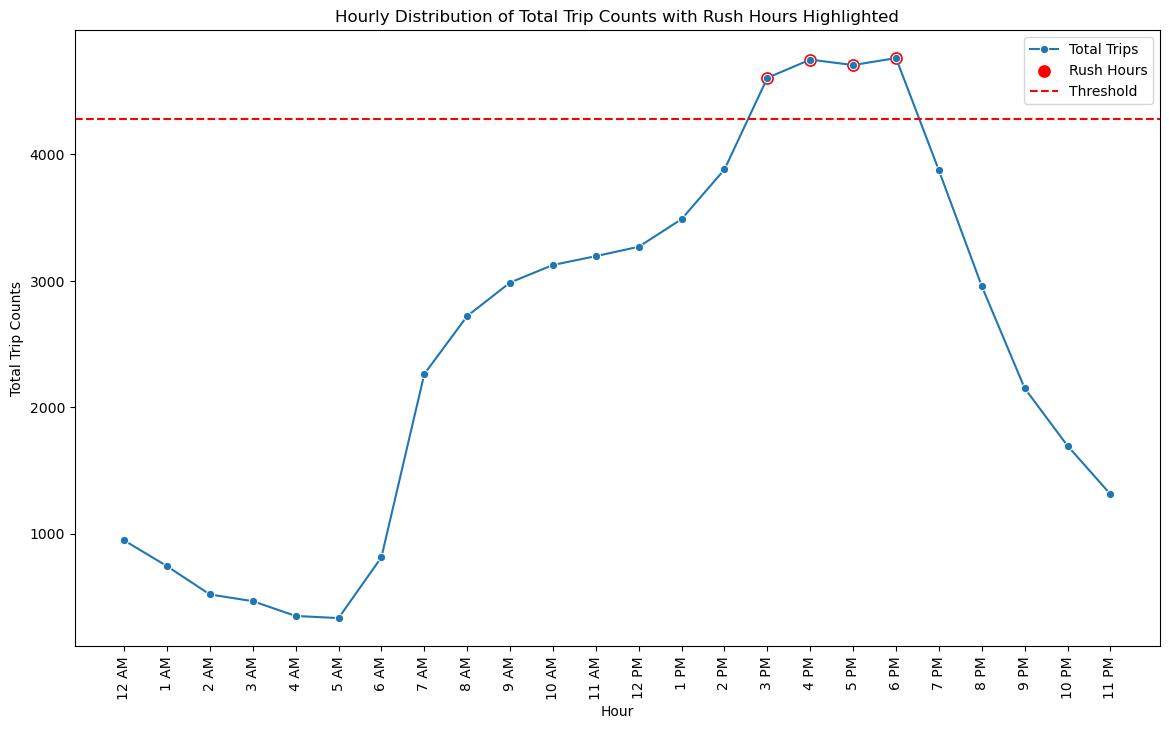

In [123]:
# Menghitung jumlah total perjalanan per jam
total_hourly_counts = df_analysis1.groupby('pickup_hour').size().reset_index(name='trip_counts')

# Menentukan jam-jam sibuk (rush hour) dengan persentil tertentu
threshold = total_hourly_counts['trip_counts'].quantile(0.85)
rush_hours = total_hourly_counts[total_hourly_counts['trip_counts'] >= threshold]

# Visualisasi jumlah total perjalanan per jam dengan menyoroti rush hour
plt.figure(figsize=(14, 8))
sns.lineplot(x='pickup_hour', y='trip_counts', data=total_hourly_counts, marker='o', label='Total Trips')
sns.scatterplot(x='pickup_hour', y='trip_counts', data=rush_hours, color='red', s=100, label='Rush Hours')
plt.axhline(y=threshold, color='red', linestyle='--', label='Threshold')
plt.title('Hourly Distribution of Total Trip Counts with Rush Hours Highlighted')
plt.xlabel('Hour')
plt.ylabel('Total Trip Counts')
plt.xticks(ticks=range(0, 24), labels=[convert_to_ampm(hour) for hour in range(0, 24)], rotation=90)
plt.legend()
plt.show()

In [124]:
# Simpan data untuk Tableau
total_hourly_counts.to_csv('hourly_trip_counts.csv', index=False)

> Lineplot di atas yang menunjukkan distribusi jumlah perjalanan secara kumulatif per jam, berikut adalah beberapa **insight** yang dapat diambil:
>
> - Dapat dilihat kenaikan volume perjalanan secara kumulatif dimulai dari jam 6 pagi dan berlanjut hingga jam 6 sore.
> - Di sini saya menggunakan persentil 0.85, untuk melihat 15% dari data yang dianggap sebagai "jam tersibuk". Hal ini membantu fokus pada jam-jam dengan aktivitas tertinggi tanpa mengabaikan pola umum.
> - Hasilnya kita mendapatkan rentang dari jam 3 sore hingga jam 6 sore sebagai waktu paling sibuk berdasarkan data.

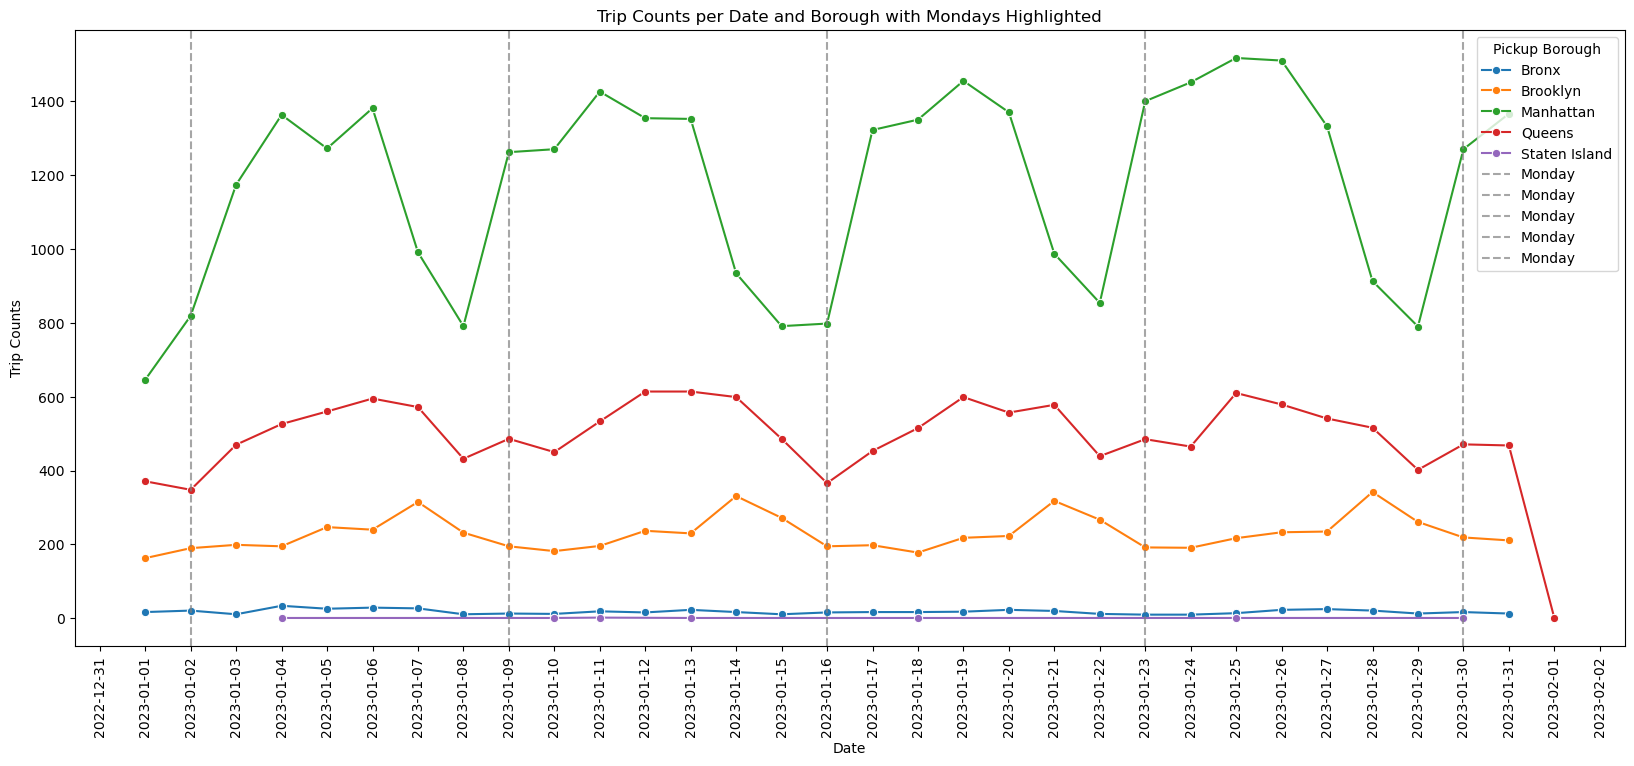

In [126]:
# Mengubah kolom waktu menjadi tanggal
df_analysis1['pickup_date'] = pd.to_datetime(df_analysis1['pickup_date']).dt.date
df_analysis1['pickup_day'] = pd.to_datetime(df_analysis1['pickup_date']).dt.day_name()

# Menghitung jumlah perjalanan per tanggal per borough
daily_counts = df_analysis1.groupby(['pickup_date', 'Pickup_Borough']).size().reset_index(name='trip_counts')

# Menghitung total jumlah perjalanan per tanggal untuk persentase
daily_total_counts = daily_counts.groupby('pickup_date')['trip_counts'].sum().reset_index(name='total_counts')

# Menggabungkan total jumlah perjalanan per tanggal dengan daily_counts
daily_counts = pd.merge(daily_counts, daily_total_counts, on='pickup_date')

# Menghitung persentase perjalanan per borough per tanggal
daily_counts['percentage'] = (daily_counts['trip_counts'] / daily_counts['total_counts']) * 100

# Membuat lineplot berdasarkan tanggal dan borough dengan anotasi persentase
plt.figure(figsize=(20, 8))
lineplot = sns.lineplot(x='pickup_date', y='trip_counts', hue='Pickup_Borough', data=daily_counts, marker='o')

# Menambahkan garis vertikal untuk setiap hari Senin
mondays = daily_counts[daily_counts['pickup_date'].apply(lambda x: x.weekday() == 0)]['pickup_date'].unique()
for monday in mondays:
    plt.axvline(x=monday,color='gray',linestyle='--',alpha=0.7,label='Monday')

# Menyesuaikan sumbu X untuk menampilkan lebih banyak tanggal
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))  # Setiap hari
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format tanggal
plt.xticks(rotation=90)


# Menambahkan judul dan label
plt.title('Trip Counts per Date and Borough with Mondays Highlighted')
plt.xlabel('Date')
plt.ylabel('Trip Counts')
plt.legend(title='Pickup Borough')
plt.show()

In [127]:
# Simpan data untuk Tableau
daily_counts.to_csv('daily_trip_counts.csv', index=False)

> Lineplot di atas yang menunjukkan distribusi jumlah perjalanan per borough per harinya, berikut adalah beberapa **insight** yang dapat diambil:
>
> - Di Manhattan, terlihat lonjakan jumlah perjalanan pada hari Senin pagi, yang mungkin mencerminkan aktivitas orang-orang yang kembali bekerja setelah akhir pekan. Ini menunjukkan bahwa hari Senin adalah salah satu hari tersibuk dalam seminggu di Manhattan.
> - Di Brooklyn dan Queens, ada variasi aktivitas perjalanan sepanjang minggu, dengan beberapa puncak pada hari Senin. Namun, lonjakan yang terlihat tidak seintens di Manhattan. Ini bisa menunjukkan bahwa meskipun ada banyak aktivitas bekerja, ada juga banyak perjalanan yang terkait dengan kegiatan lain, seperti sekolah atau aktivitas sosial.
> - Di Bronx dan Staten Island, volume perjalanan terlihat lebih stabil dengan tidak banyak variasi dari hari ke hari. Hal ini menunjukkan bahwa pola perjalanan di borough-borough ini mungkin lebih dipengaruhi oleh faktor-faktor lokal atau demografi yang berbeda dibandingkan dengan Manhattan.

## Identifikasi Zona dengan Tingkat Kemacetan yang Tinggi

In [130]:
# Filter kolom yang akan digunakan
df_analysis2 = df[['Pickup_Borough', 'Dropoff_Borough', 'speed(mph)', 'duration_hrs', 'congestion_surcharge']]

df_analysis2['pickup_hour'] = df['lpep_pickup_datetime'].dt.hour
df_analysis2['dropoff_hour'] = df['lpep_dropoff_datetime'].dt.hour

df_analysis2['pickup_day'] = df['lpep_pickup_datetime'].dt.dayofweek  # 0 = Senin, 6 = Minggu
df_analysis2['dropoff_day'] = df['lpep_dropoff_datetime'].dt.dayofweek  # 0 = Senin, 6 = Minggu

df_analysis2['pickup_date'] = pd.to_datetime(df['lpep_pickup_datetime'].dt.date)
df_analysis2['dropoff_date'] = pd.to_datetime(df['lpep_dropoff_datetime'].dt.date)

df_analysis2['route_borough'] = df['Pickup_Borough'].astype(str) + ' - ' + df['Dropoff_Borough'].astype(str)

df_analysis2

,Pickup_Borough,Dropoff_Borough,speed(mph),duration_hrs,congestion_surcharge,pickup_hour,dropoff_hour,pickup_day,dropoff_day,pickup_date,dropoff_date,route_borough
0,Manhattan,Manhattan,14.05,0.183611,2.75,0,0,6,6,2023-01-01,2023-01-01,Manhattan - Manhattan
1,Manhattan,Manhattan,16.05,0.112778,0.00,0,0,6,6,2023-01-01,2023-01-01,Manhattan - Manhattan
2,Manhattan,Manhattan,13.41,0.096944,0.00,0,0,6,6,2023-01-01,2023-01-01,Manhattan - Manhattan
3,Manhattan,Manhattan,11.06,0.099444,0.00,0,0,6,6,2023-01-01,2023-01-01,Manhattan - Manhattan
4,Manhattan,Manhattan,9.50,0.292500,2.75,0,1,6,6,2023-01-01,2023-01-01,Manhattan - Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...
60315,Queens,Queens,20.67,0.133056,0.00,23,23,1,1,2023-01-31,2023-01-31,Queens - Queens
60316,Brooklyn,Brooklyn,13.62,0.179167,0.00,23,23,1,1,2023-01-31,2023-01-31,Brooklyn - Brooklyn
60317,Manhattan,Manhattan,13.96,0.100278,0.00,23,23,1,1,2023-01-31,2023-01-31,Manhattan - Manhattan
60318,Manhattan,Manhattan,15.55,0.158889,2.75,23,23,1,1,2023-01-31,2023-01-31,Manhattan - Manhattan


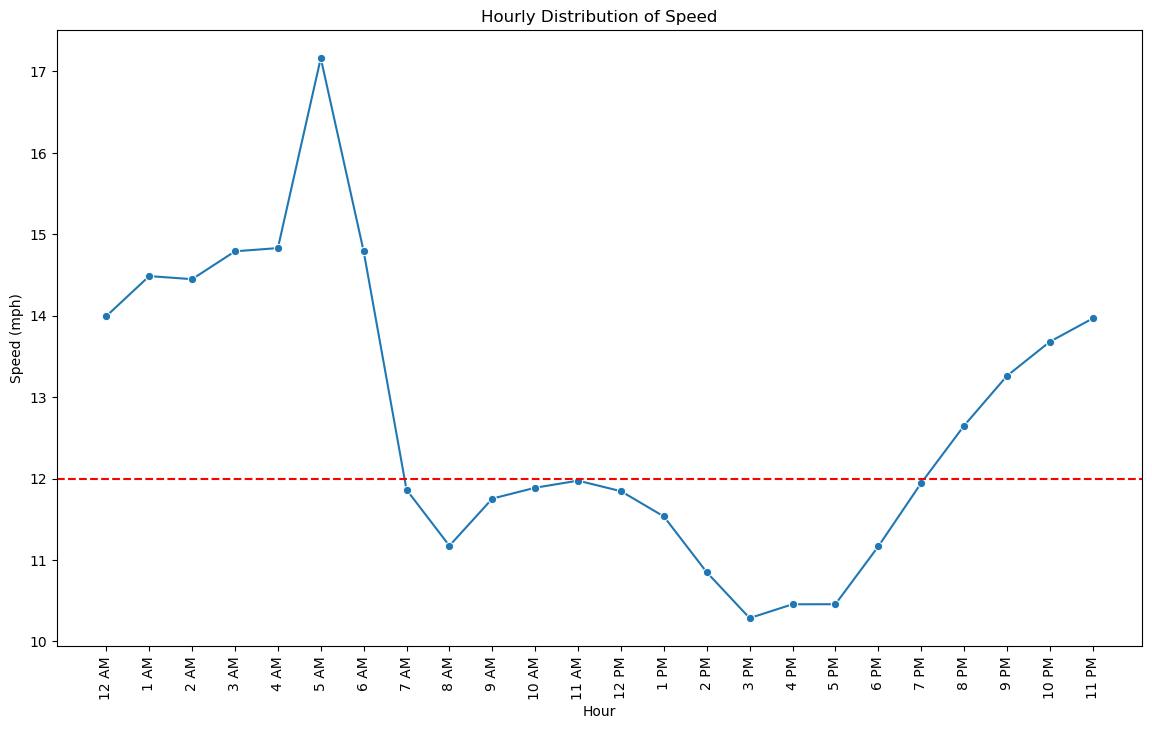

In [131]:
average_speed_per_hour = df_analysis2.groupby('pickup_hour')['speed(mph)'].mean()

plt.figure(figsize=(14, 8))
sns.lineplot(x=average_speed_per_hour.index, y=average_speed_per_hour.values, marker='o')
plt.axhline(y=12, color='red', linestyle='--', label='Threshold (Speed = 12 mph)')
plt.title('Hourly Distribution of Speed')
plt.xlabel('Hour')
plt.ylabel('Speed (mph)')
plt.xticks(ticks=range(0, 24), labels=[convert_to_ampm(hour) for hour in range(0, 24)], rotation=90)
plt.show()

In [132]:
# Simpan data untuk Tableau
speed_per_hour = df_analysis2[['pickup_hour', 'speed(mph)']]
speed_per_hour.to_csv('speed_per_hour.csv', index=False)

> Pada saat keadaan jalan macet di New York City, kecepatan kendaraan pada umumnya dapat menyentuh hingga 12 mph. Berdasarkan informasi ini, saya membuat ambang batas bahwa bagi perjalanan dengan kecepatan di bawah 12 dapat mengindikasikan adanya kemacetan pada jam tertentu.
>
> Sumber: [Threshold 12 mph](https://nypost.com/2023/03/13/nyc-drivers-travel-just-12-mph-during-rush-hour/#:~:text=A%20New%20York%20minute%20is,times%2C%20newly%20published%20data%20shows.)
>
> Lineplot di atas yang menunjukkan tren rata-rata dari kecepatan per jam, berikut adalah beberapa **insight** yang dapat diambil:
> 
> - Rata-rata kecepatan berada di bawah garis batas 12 mph mulai dari jam 7 pagi hingga jam 7 malam.
> - Pada jam 3 sore hingga jam 5 sore, kecepatan sangat rendah, ini dapat mengindikasikan bahwa terdapat kemacetan pada jam-jam tersebut.

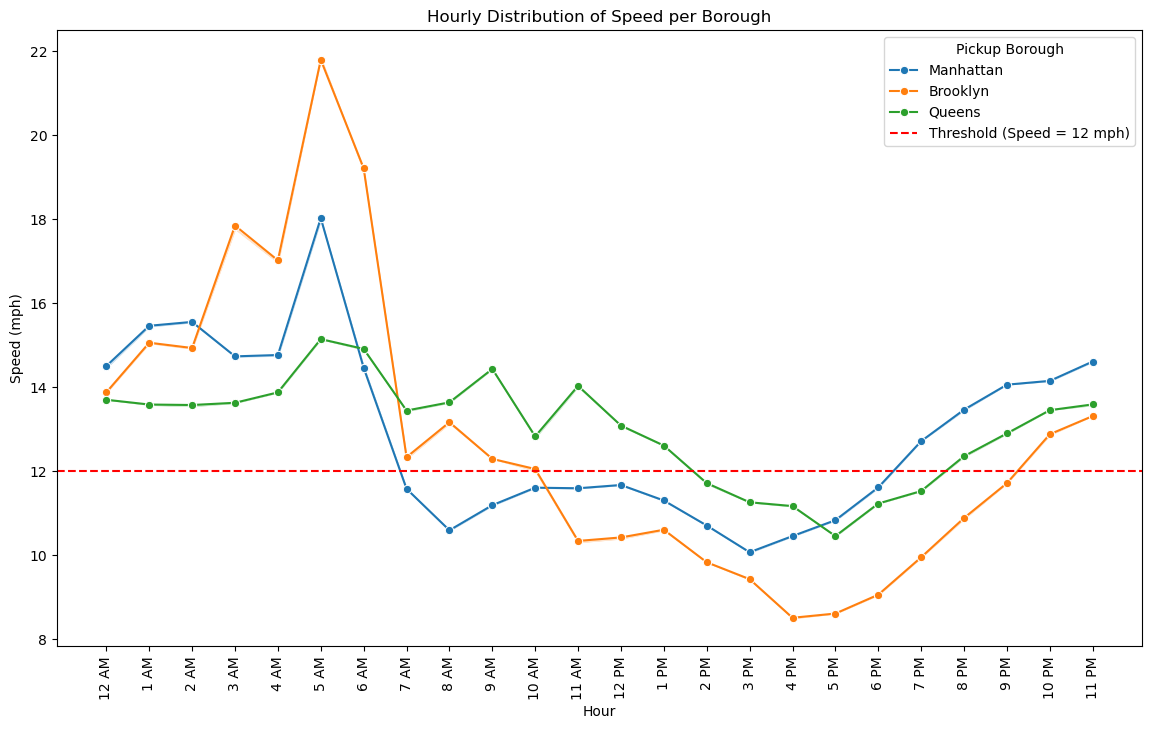

In [134]:
# Filter data untuk borough tertentu
filtered_data = df_analysis2[df_analysis2['Pickup_Borough'].isin(['Manhattan', 'Queens', 'Brooklyn'])]

# Plot data filter
plt.figure(figsize=(14, 8))
sns.lineplot(x='pickup_hour', y='speed(mph)', hue='Pickup_Borough', data=filtered_data, marker='o', ci=False)
plt.axhline(y=12, color='red', linestyle='--', label='Threshold (Speed = 12 mph)')
plt.title('Hourly Distribution of Speed per Borough')
plt.xlabel('Hour')
plt.ylabel('Speed (mph)')
plt.xticks(ticks=range(0, 24), labels=[convert_to_ampm(hour) for hour in range(0, 24)], rotation=90)
plt.legend(title='Pickup Borough')
plt.show()

In [135]:
# Simpan data untuk Tableau
speed_per_hour_boro = df_analysis2[['pickup_hour', 'speed(mph)', 'Pickup_Borough']]
speed_per_hour_boro.to_csv('speed_per_hour_boro.csv', index=False)

> Pada lineplot di atas saya mengambil 3 daerah dengan tingkat volume perjalanan terpadat.
> 
> Lineplot menunjukkan tren rata-rata dari kecepatan per jam, berikut adalah beberapa **insight** yang dapat diambil:
>
> - Kecepatan di Brooklyn menunjukkan variasi yang signifikan sepanjang hari, dengan kecepatan tertinggi sekitar pukul 5 pagi. Ini menunjukkan bahwa jalan-jalan di Brooklyn mungkin lebih kosong dan perjalanan lebih lancar pada jam-jam awal pagi. Namun, kecepatan menurun drastis sepanjang hari, mengindikasikan adanya peningkatan kemacetan saat hari berlangsung.
> - Kecepatan kendaraan di Manhattan dan Queens cenderung lebih stabil sepanjang hari, meskipun ada sedikit variasi. Kecepatan di kedua borough ini lebih rendah dibandingkan dengan Brooklyn pada pagi hari, menunjukkan bahwa ada kemungkinan bahwa kemacetan lebih merata sepanjang hari.
> - Manhattan menunjukkan pola stabil dengan sedikit penurunan kecepatan selama jam sibuk (pagi dan sore hari), tetapi umumnya mempertahankan kecepatan yang cukup konsisten.

In [137]:
# Definisikan ambang batas
speed_threshold = 12

# Buat kolom baru untuk filter data yang kita anggap kemacetan
df_analysis2['is_congested'] = df_analysis2['speed(mph)'] < speed_threshold

# Hitung data kemacetan per borough
congested_trips_per_borough = df_analysis2.groupby('Pickup_Borough')['is_congested'].sum().reset_index()

# Hitung total trip per borough
total_trips_per_borough = df_analysis2.groupby('Pickup_Borough')['Pickup_Borough'].count().reset_index(name='total_trips')

# Merge data
congestion_data = pd.merge(congested_trips_per_borough, total_trips_per_borough, on='Pickup_Borough')

# Kalkulasi persentase
congestion_data['congestion_percentage'] = (congestion_data['is_congested'] / congestion_data['total_trips']) * 100

congestion_data

,Pickup_Borough,is_congested,total_trips,congestion_percentage
0,Bronx,337,556,60.611511
1,Brooklyn,5067,7122,71.145746
2,Manhattan,23728,36511,64.988634
3,Queens,9486,15701,60.416534
4,Staten Island,4,8,50.000000


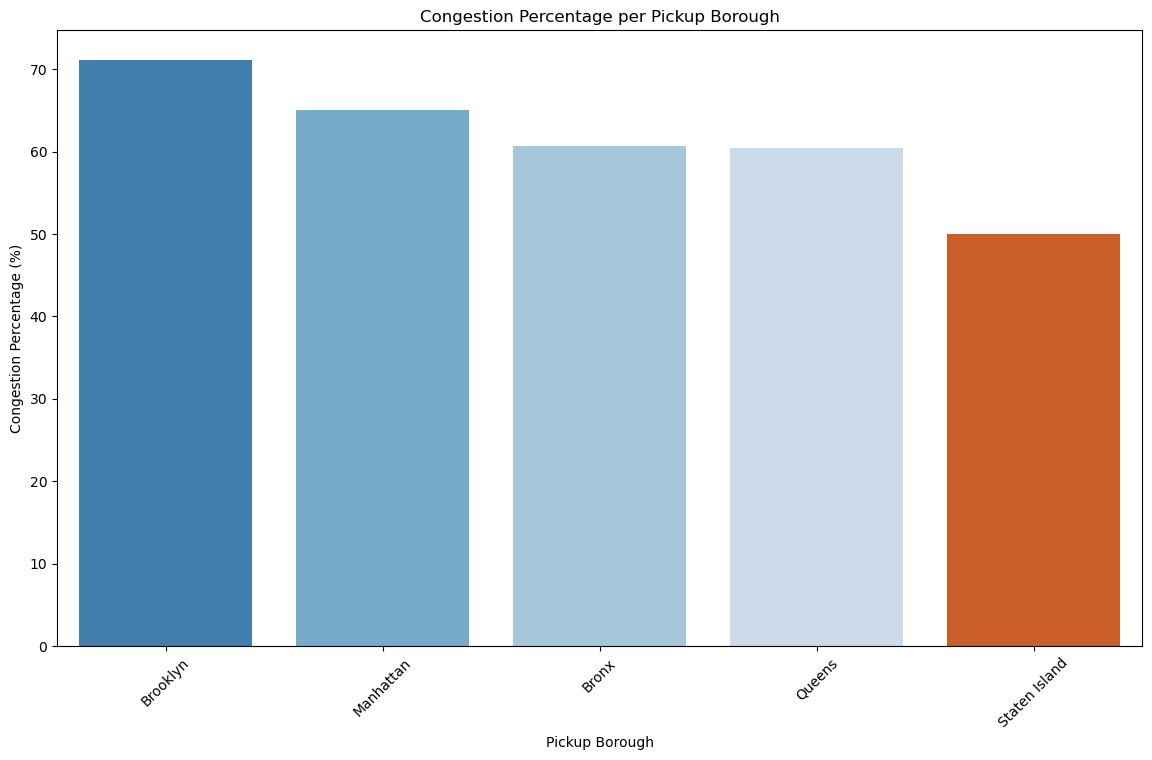

In [138]:
# Sort data
congestion_data_sorted = congestion_data.sort_values(by='congestion_percentage', ascending=False)

# Barplot
plt.figure(figsize=(14, 8))
sns.barplot(x='Pickup_Borough', y='congestion_percentage', data=congestion_data_sorted, palette='tab20c')

# Tempelkan title and labels
plt.title('Congestion Percentage per Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Congestion Percentage (%)')

# Rotate x-axis labels
plt.xticks(rotation=45)

plt.show()

In [139]:
# Simpan data untuk Tableau
congestion_data.to_csv('congestion_data.csv', index=False)

> Barplot di atas menunjukkan besar persentase kemacetan pada trip per Pickup Borough, berikut **insight** yang dapat diambil:
>
> - Brooklyn memiliki persentase kemacetan tertinggi sekitar 70%. Ini menunjukkan bahwa lalu lintas di Brooklyn sangat padat dan membutuhkan perhatian lebih dalam hal manajemen lalu lintas dan pengembangan infrastruktur.
> - Manhattan, meskipun tidak sepadat Brooklyn, tetap menunjukkan tingkat kemacetan yang signifikan. Mengingat Manhattan adalah pusat bisnis dan komersial utama, tingkat kemacetan yang tinggi mungkin diharapkan tetapi tetap membutuhkan solusi untuk meningkatkan efisiensi transportasi.
> - Bronx dan Queens memiliki tingkat kemacetan yang lebih rendah dibandingkan Brooklyn dan Manhattan, tetapi tetap cukup signifikan. Ini menunjukkan adanya potensi peningkatan dalam manajemen lalu lintas di kedua borough ini untuk mengurangi kemacetan.
> - Staten Island memiliki persentase kemacetan terendah. Ini mungkin disebabkan oleh kepadatan penduduk yang lebih rendah atau sistem transportasi yang lebih efisien di borough ini. Namun, meskipun kemacetan rendah, penting untuk memastikan bahwa infrastruktur transportasi tetap terjaga untuk mencegah peningkatan kemacetan di masa depan.

In [141]:
# Definisikan ambang batas
speed_threshold = 12

# Buat kolom baru untuk filter data yang kita anggap kemacetan
df_analysis2['is_congested'] = df_analysis2['speed(mph)'] < speed_threshold

# Hitung data kemacetan per borough
congested_trips_per_borough_do = df_analysis2.groupby('Dropoff_Borough')['is_congested'].sum().reset_index()

# Hitung total trip per borough
total_trips_per_borough_do = df_analysis2.groupby('Dropoff_Borough')['Dropoff_Borough'].count().reset_index(name='total_trips')

# Merge data
congestion_data_do = pd.merge(congested_trips_per_borough_do, total_trips_per_borough_do, on='Dropoff_Borough')

# Kalkulasi persentase
congestion_data_do['congestion_percentage_do'] = (congestion_data_do['is_congested'] / congestion_data_do['total_trips']) * 100

congestion_data_do

,Dropoff_Borough,is_congested,total_trips,congestion_percentage_do
0,Bronx,820,1726,47.508691
1,Brooklyn,4770,6196,76.985152
2,EWR,0,20,0.000000
3,Manhattan,23768,36425,65.251887
4,Queens,9260,15523,59.653418
5,Staten Island,4,8,50.000000


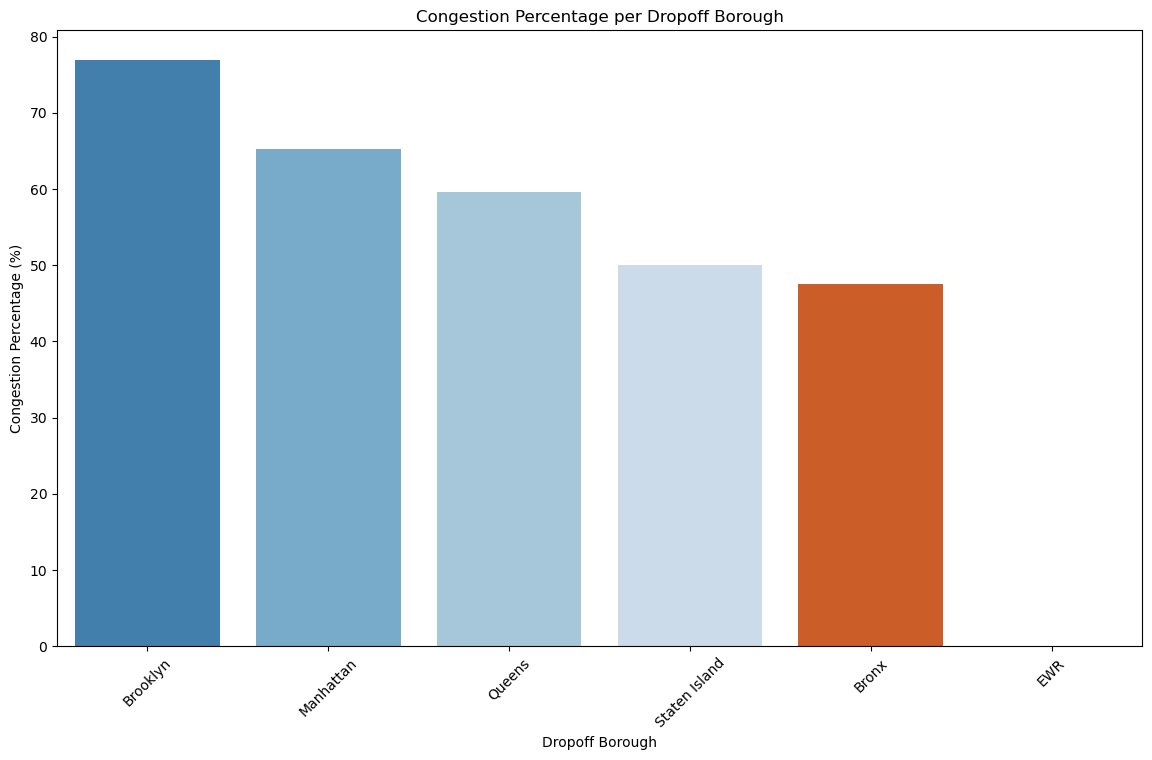

In [142]:
# Sort data 
congestion_data_do_sorted = congestion_data_do.sort_values(by='congestion_percentage_do', ascending=False)

# Bar plot
plt.figure(figsize=(14, 8))
sns.barplot(x='Dropoff_Borough', y='congestion_percentage_do', data=congestion_data_do_sorted, palette='tab20c')

# Tetapkan title dan labels
plt.title('Congestion Percentage per Dropoff Borough')
plt.xlabel('Dropoff Borough')
plt.ylabel('Congestion Percentage (%)')

# Rotate x-axis labels
plt.xticks(rotation=45)

plt.show()

In [143]:
# Simpan data untuk Tableau
congestion_data_do.to_csv('congestion_data_do.csv', index=False)

> Barplot di atas menunjukkan besar persentase kemacetan pada trip per Dropoff Borough, berikut **insight** yang dapat diambil:
>
> - Wilayah Brooklyn memiliki tingkat kemacetan tertinggi di antara wilayah lainnya, dengan persentase kemacetan melebihi 70%. Ini menunjukkan bahwa lalu lintas di Brooklyn sangat padat dan lambat dibandingkan dengan wilayah lainnya.
> - Wilayah Manhattan dan Queens juga mengalami tingkat kemacetan yang tinggi, masing-masing sekitar 65% dan 60%.
> - Staten Island dan Bronx memiliki persentase kemacetan terendah, ini dapat dikarenakan karakteristik demografi yang berbeda dengan borough dengan tingkat kemacetan tertinggi.
> - EWR yang merupakan bandara tidak memiliki tingkat kemacetan, artinya untuk perjalanan menuju bandara jalanan bebas dari kemacetan.

In [145]:
# Definisikan ambang batas
speed_threshold = 12

# Buat kolom baru untuk filter data yang kita anggap kemacetan
df_analysis2['is_congested'] = df_analysis2['speed(mph)'] < speed_threshold

# Hitung data kemacetan per borough
congested_trips_route = df_analysis2.groupby('route_borough')['is_congested'].sum().reset_index()

# Hitung total trip per borough
total_trips_route = df_analysis2.groupby('route_borough')['route_borough'].count().reset_index(name='total_trips')

# Merge data
congestion_data_route = pd.merge(congested_trips_route, total_trips_route, on='route_borough')

# Kalkulasi persentase
congestion_data_route['congestion_percentage_rou'] = (congestion_data_route['is_congested'] / congestion_data_route['total_trips']) * 100

congestion_data_route

,route_borough,is_congested,total_trips,congestion_percentage_rou
0,Bronx - Bronx,244,387,63.049096
1,Bronx - Brooklyn,0,2,0.000000
2,Bronx - Manhattan,91,152,59.868421
3,Bronx - Queens,2,15,13.333333
4,Brooklyn - Bronx,0,9,0.000000
5,Brooklyn - Brooklyn,4662,5583,83.503493
6,Brooklyn - EWR,0,7,0.000000
7,Brooklyn - Manhattan,367,1231,29.813160
8,Brooklyn - Queens,38,291,13.058419
9,Brooklyn - Staten Island,0,1,0.000000


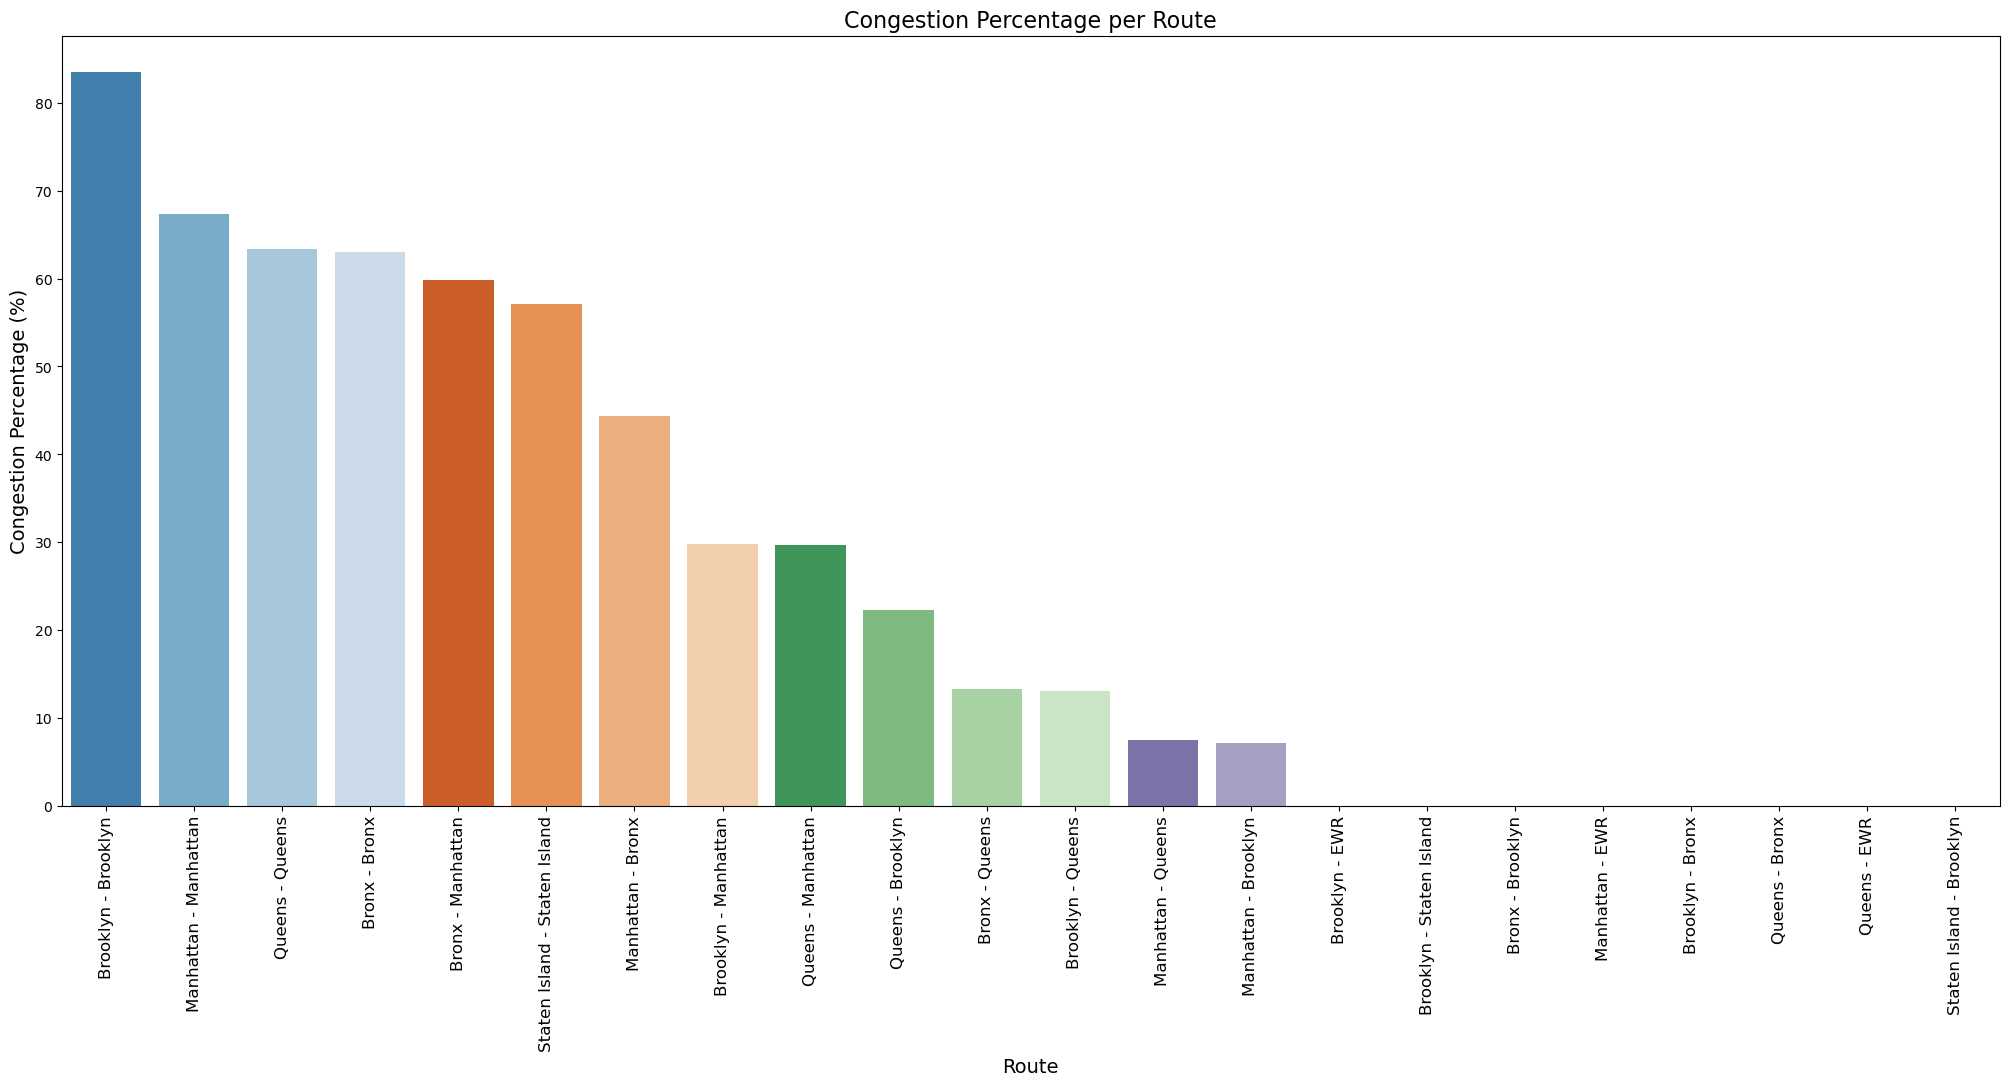

In [146]:
# Sort data
congestion_data_route_sorted = congestion_data_route.sort_values(by='congestion_percentage_rou', ascending=False)

# Bar plot
plt.figure(figsize=(25, 10))
sns.barplot(x='route_borough', y='congestion_percentage_rou', data=congestion_data_route_sorted, palette='tab20c')

# Tetapkan title dan labels
plt.title('Congestion Percentage per Route', fontsize=16)
plt.xlabel('Route', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.ylabel('Congestion Percentage (%)', fontsize=14)

plt.show()

In [147]:
# Simpan data untuk Tableau
congestion_data_route.to_csv('congestion_data_route.csv', index=False)

> Barplot di atas menunjukkan besar persentase kemacetan pada trip per Pickup Borough, berikut **insight** yang dapat diambil:
>
> - Rute "Brooklyn - Brooklyn" memiliki persentase kemacetan tertinggi, yaitu di atas 80%. Ini menunjukkan bahwa lalu lintas di dalam Brooklyn sangat padat. Ini bisa jadi disebabkan oleh tingginya kepadatan penduduk, jumlah kendaraan pribadi, dan mungkin terbatasnya infrastruktur jalan yang memadai untuk menampung volume lalu lintas yang besar.
> - Rute "Manhattan - Manhattan" juga menunjukkan tingkat kemacetan yang tinggi, di atas 60%. Ini mencerminkan fakta bahwa Manhattan adalah pusat bisnis dan komersial utama, yang menyebabkan lalu lintas yang sangat padat selama jam-jam sibuk.
> - Rute "Bronx - Bronx" dan "Queens - Queens" juga menunjukkan tingkat kemacetan yang cukup tinggi, masing-masing di atas 60%. Ini menunjukkan bahwa ada kemacetan signifikan dalam pergerakan internal di kedua borough ini, yang bisa disebabkan oleh kombinasi faktor-faktor seperti infrastruktur yang terbatas dan volume kendaraan yang tinggi.
> - Dengan membandingkan rute-rute yang ada, kita dapat melihat bahwa kemacetan tidak hanya terjadi dalam pergerakan internal borough, tetapi juga dalam pergerakan antar borough. Namun, pergerakan internal dalam borough tertentu seperti Brooklyn dan Manhattan cenderung lebih padat.

## Identifikasi Faktor yang Mempengaruhi Jumlah Tip

In [150]:
df_analysis3 = df[["trip_distance", "fare_amount", "tip_amount", "payment_type", "Pickup_Borough", "Dropoff_Borough", "lpep_pickup_datetime", "lpep_dropoff_datetime", "duration_hrs", "speed(mph)"]]
df_analysis3['pickup_date'] = pd.to_datetime(df['lpep_pickup_datetime'].dt.date)
df_analysis3['dropoff_date'] = pd.to_datetime(df['lpep_dropoff_datetime'].dt.date)
df_analysis3['pickup_hour'] = df['lpep_pickup_datetime'].dt.hour
df_analysis3['dropoff_hour'] = df['lpep_dropoff_datetime'].dt.hour
df_analysis3['route_borough'] = df['Pickup_Borough'].astype(str) + ' - ' + df['Dropoff_Borough'].astype(str)

df_analysis3

,trip_distance,fare_amount,tip_amount,payment_type,Pickup_Borough,Dropoff_Borough,lpep_pickup_datetime,lpep_dropoff_datetime,duration_hrs,speed(mph),pickup_date,dropoff_date,pickup_hour,dropoff_hour,route_borough
0,2.58,14.9,4.03,1.0,Manhattan,Manhattan,2023-01-01 00:26:10,2023-01-01 00:37:11,0.183611,14.05,2023-01-01,2023-01-01,0,0,Manhattan - Manhattan
1,1.81,10.7,2.64,1.0,Manhattan,Manhattan,2023-01-01 00:51:03,2023-01-01 00:57:49,0.112778,16.05,2023-01-01,2023-01-01,0,0,Manhattan - Manhattan
2,1.30,6.5,1.70,1.0,Manhattan,Manhattan,2023-01-01 00:13:14,2023-01-01 00:19:03,0.096944,13.41,2023-01-01,2023-01-01,0,0,Manhattan - Manhattan
3,1.10,6.0,0.00,1.0,Manhattan,Manhattan,2023-01-01 00:33:04,2023-01-01 00:39:02,0.099444,11.06,2023-01-01,2023-01-01,0,0,Manhattan - Manhattan
4,2.78,17.7,0.00,2.0,Manhattan,Manhattan,2023-01-01 00:53:31,2023-01-01 01:11:04,0.292500,9.50,2023-01-01,2023-01-01,0,1,Manhattan - Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60315,2.75,15.0,2.00,1.0,Queens,Queens,2023-01-31 23:09:22,2023-01-31 23:17:21,0.133056,20.67,2023-01-31,2023-01-31,23,23,Queens - Queens
60316,2.44,13.5,3.20,1.0,Brooklyn,Brooklyn,2023-01-31 23:06:18,2023-01-31 23:17:03,0.179167,13.62,2023-01-31,2023-01-31,23,23,Brooklyn - Brooklyn
60317,1.40,9.3,2.36,1.0,Manhattan,Manhattan,2023-01-31 23:17:03,2023-01-31 23:23:04,0.100278,13.96,2023-01-31,2023-01-31,23,23,Manhattan - Manhattan
60318,2.47,13.5,3.75,1.0,Manhattan,Manhattan,2023-01-31 23:29:18,2023-01-31 23:38:50,0.158889,15.55,2023-01-31,2023-01-31,23,23,Manhattan - Manhattan


In [151]:
df['tip_amount'].describe()

count    59898.000000
mean         2.098561
std          2.784426
min          0.000000
25%          0.000000
50%          1.660000
75%          3.280000
max         80.880000
Name: tip_amount, dtype: float64

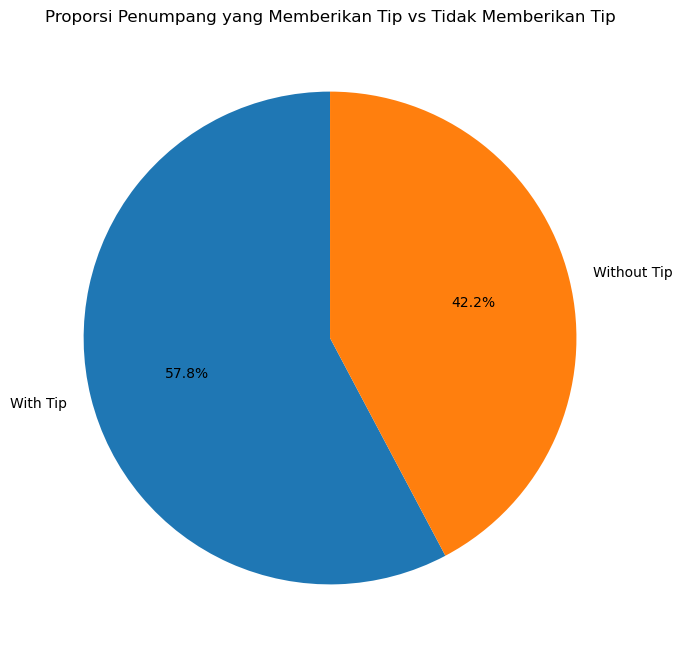

In [152]:
# Hitung jumlah total trip
row_num = df.shape[0]

# Hitung jumlah trip dengan tip dan tanpa tip
total_trips_with_tip = df[df['tip_amount'] > 0].shape[0]
total_trips_without_tip = df[df['tip_amount'] == 0].shape[0]

# Buat DataFrame baru untuk proporsi
proporsi_df = pd.DataFrame({'Category': ['With Tip', 'Without Tip'], 'Count': [total_trips_with_tip, total_trips_without_tip]})

# Buat pie chart
plt.figure(figsize=(8, 8))
plt.pie(proporsi_df['Count'], labels=proporsi_df['Category'], autopct='%1.1f%%', startangle=90)
plt.title('Proporsi Penumpang yang Memberikan Tip vs Tidak Memberikan Tip')
plt.show()

In [153]:
# Save data untuk Tableau
proporsi_df.to_csv('proporsi_df.csv', index=False)

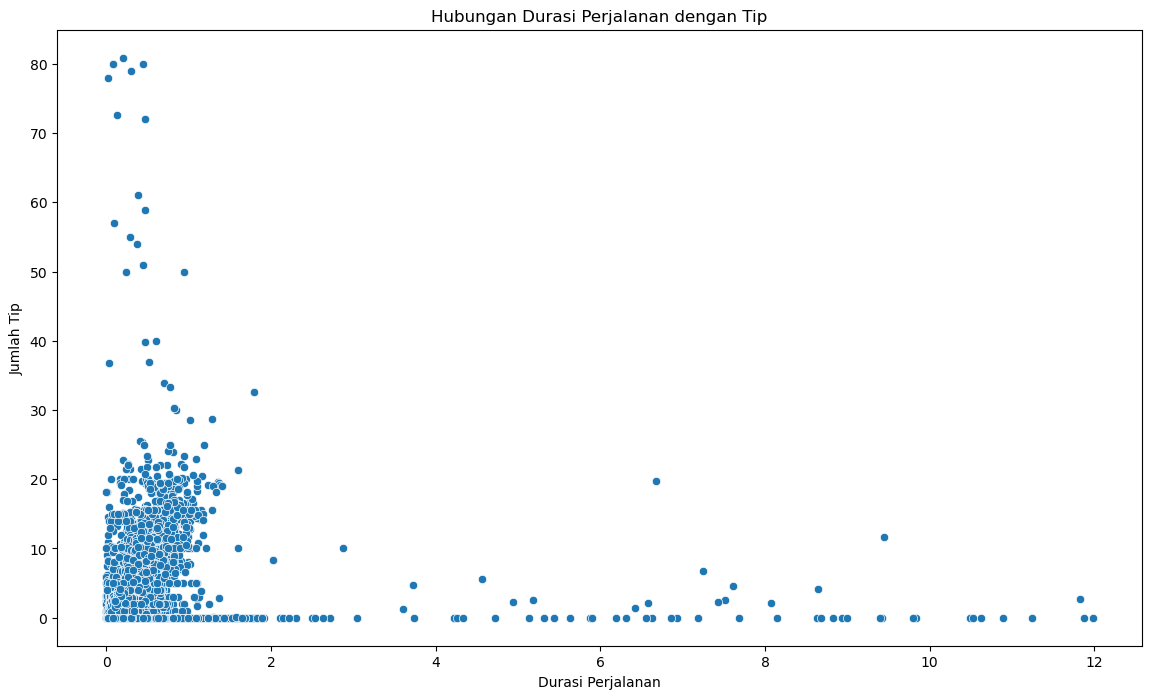

In [154]:
plt.figure(figsize=(14, 8))
sns.scatterplot(x=df_analysis3['duration_hrs'], y=df_analysis3['tip_amount'])
plt.title("Hubungan Durasi Perjalanan dengan Tip")
plt.xlabel("Durasi Perjalanan")
plt.ylabel("Jumlah Tip")
plt.show()

>Grafik ini menunjukkan hubungan antara durasi perjalanan (dalam satuan jam) dengan jumlah tip yang diberikan. 
>Berikut adalah beberapa insight yang bisa diambil dari grafik tersebut:
>
>- Sebaran Data: Sebagian besar data terkonsentrasi di area durasi perjalanan yang singkat (0-2 jam) dengan besaran tip yang bervariasi. Hal ini mengindikasikan bahwa banyak pelanggan melakukan perjalanan singkat dan memberikan tip dengan nilai yang beragam.
>- Tren Umum: Tidak terlihat adanya tren linear yang kuat antara durasi perjalanan dan besaran tip. Artinya, semakin lama durasi perjalanan, belum tentu tip yang diberikan semakin besar.

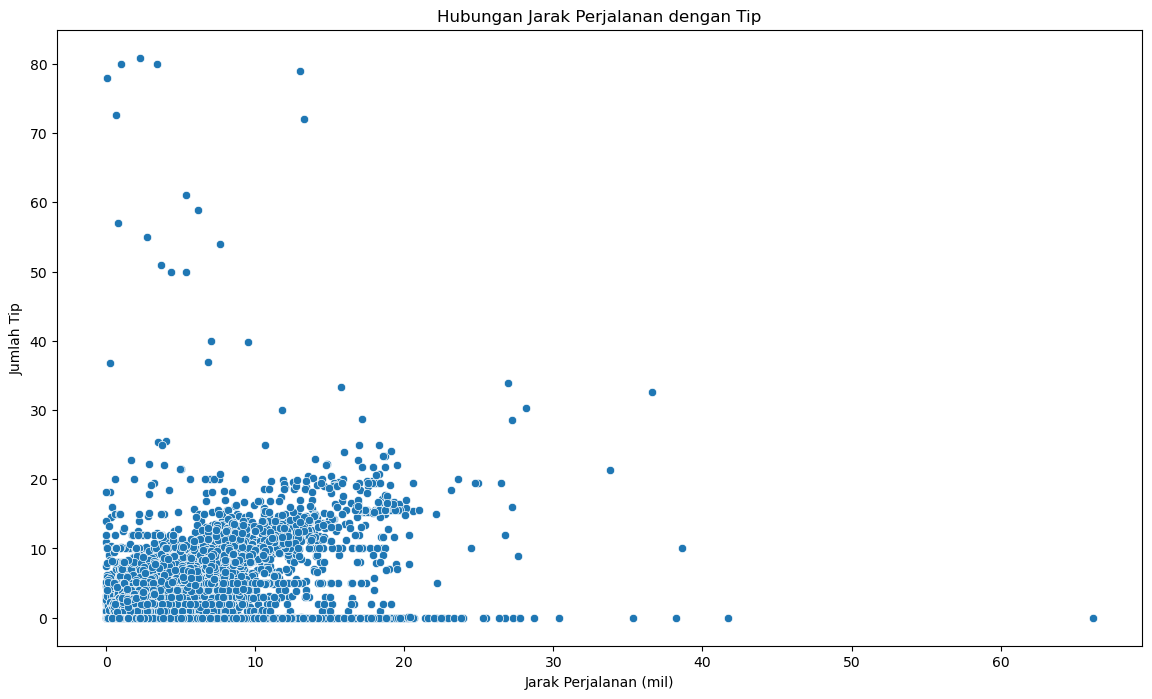

In [156]:
plt.figure(figsize=(14, 8))
sns.scatterplot(x=df_analysis3['trip_distance'], y=df_analysis3['tip_amount'])
plt.title("Hubungan Jarak Perjalanan dengan Tip")
plt.xlabel("Jarak Perjalanan (mil)")
plt.ylabel("Jumlah Tip")
plt.show()

> Grafik ini menunjukkan hubungan antara durasi perjalanan (dalam satuan jam) dengan jumlah tip yang diberikan. 
Berikut adalah beberapa insight yang bisa diambil dari grafik tersebut:

> - Korelasi Positif: Terdapat kecenderungan bahwa semakin jauh jarak perjalanan, semakin besar pula tip yang diberikan. Artinya, umumnya pelanggan memberikan tip yang lebih besar untuk perjalanan yang lebih jauh.
> - Variasi Tip: Meskipun ada kecenderungan positif, kita juga melihat bahwa untuk jarak perjalanan yang sama, jumlah tip yang diberikan sangat bervariasi. Ini menunjukkan bahwa faktor lain selain jarak juga mempengaruhi besarnya tip.

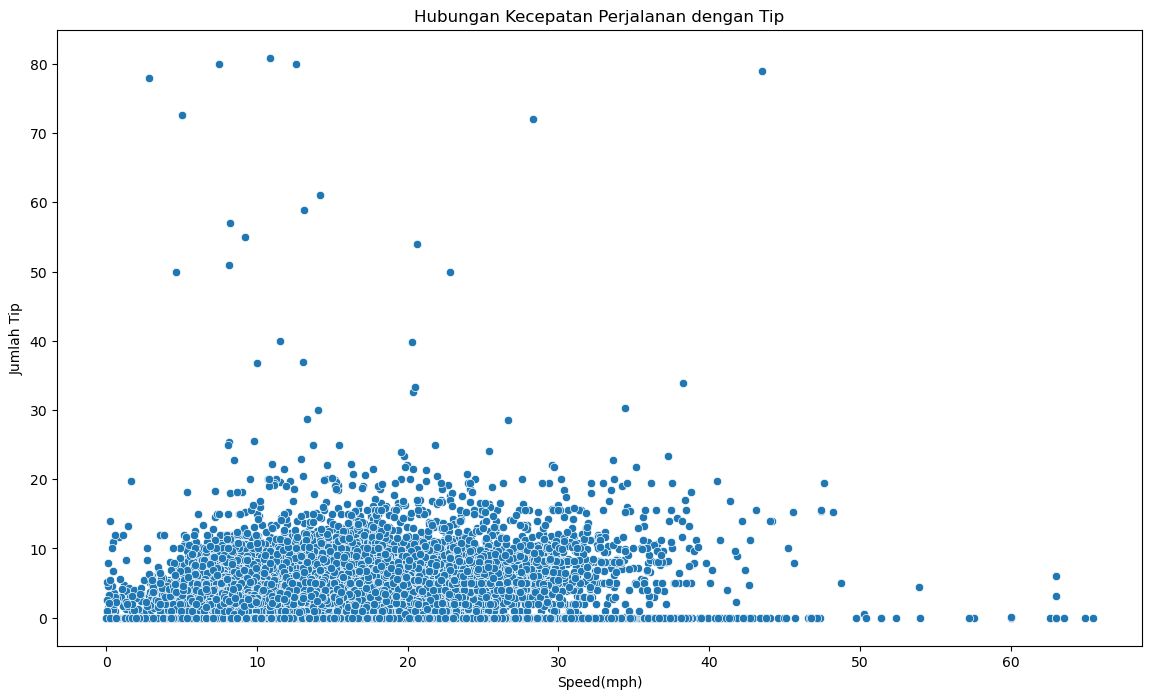

In [158]:
plt.figure(figsize=(14, 8))
sns.scatterplot(x=df_analysis3['speed(mph)'], y=df_analysis3['tip_amount'])
plt.title("Hubungan Kecepatan Perjalanan dengan Tip")
plt.xlabel("Speed(mph)")
plt.ylabel("Jumlah Tip")
plt.show()

In [159]:
# Simpan data untuk Tableau
df_analysis3.to_csv('df_analysis3.csv', index=False)

> Grafik ini menunjukkan hubungan antara kecepatan(mph) dengan jumlah tip yang diberikan. 
Berikut adalah beberapa insight yang bisa diambil dari grafik tersebut:
>
> - Meskipun ada banyak data pada kecepatan rendah dan tip rendah, kita juga melihat beberapa outlier pada kecepatan yang lebih tinggi dan tip yang lebih tinggi. Ini mungkin menunjukkan bahwa perjalanan yang lebih cepat dan lebih lancar cenderung menghasilkan tip yang lebih tinggi, mungkin karena penumpang lebih puas dengan perjalanan yang cepat.
> - Pola dalam scatter plot ini menunjukkan bahwa hubungan antara kecepatan dan jumlah tip mungkin non-linear. Artinya, tidak selalu kecepatan yang lebih tinggi menghasilkan tip yang lebih tinggi, dan ada faktor lain yang mempengaruhi keputusan penumpang untuk memberikan tip.

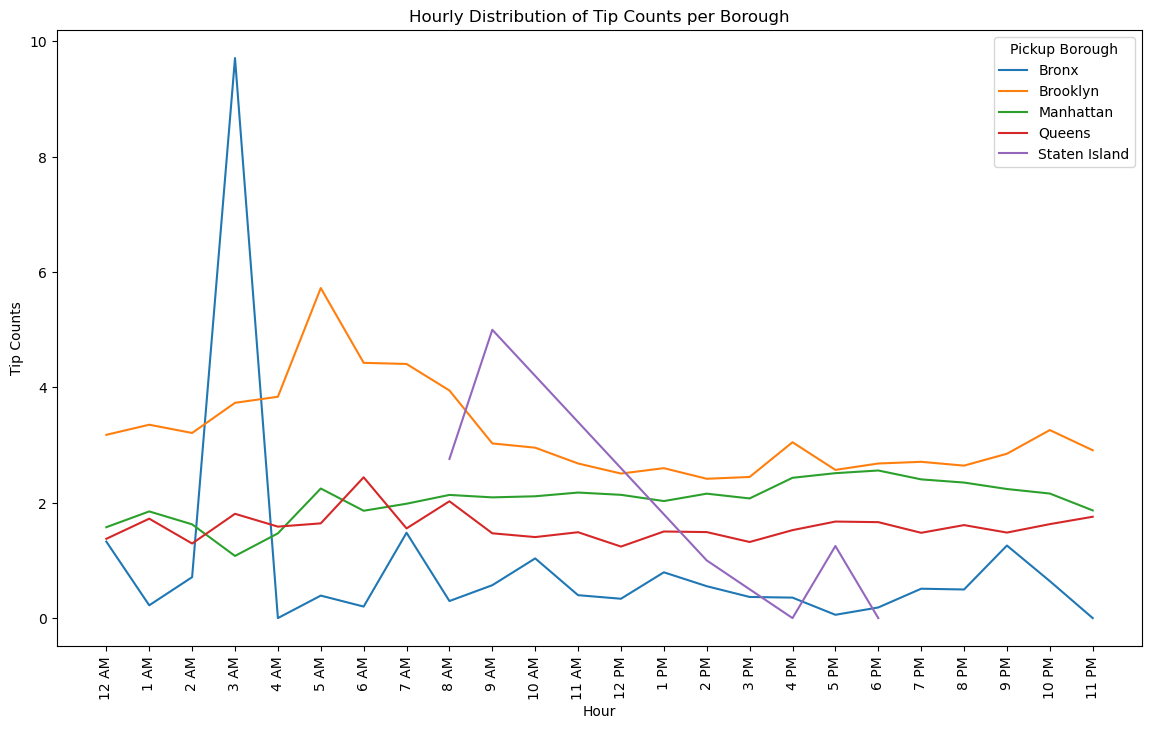

In [291]:
# Pastikan kolom tip_amount memiliki tipe data numerik
df_analysis3['tip_amount'] = pd.to_numeric(df_analysis3['tip_amount'], errors='coerce')

# Menghitung jumlah tip rata-rata per jam per Borough
tip_counts_bor = df_analysis3.groupby(['pickup_hour', 'Pickup_Borough'])['tip_amount'].mean().reset_index(name='tip_counts')

# Menghasilkan lineplot
plt.figure(figsize=(14, 8))
sns.lineplot(x='pickup_hour', y='tip_counts', hue='Pickup_Borough', data=tip_counts_bor, ci=False)
plt.title('Hourly Distribution of Tip Counts per Borough')
plt.xlabel('Hour')
plt.ylabel('Tip Counts')
plt.xticks(ticks=range(0, 24), labels=[convert_to_ampm(hour) for hour in range(0, 24)], rotation=90)
plt.legend(title='Pickup Borough')
plt.show()

> Lineplot ini menunjukkan hubungan antara jumlah pemberian tip dengan jam dan dipisahkan berdasarkan area penjemputan. 
Berikut adalah beberapa insight yang bisa diambil dari grafik tersebut:
> 
> - Brooklyn secara konsisten memiliki jumlah tip yang lebih tinggi sepanjang hari dibandingkan dengan borough lainnya, dengan lonjakan signifikan sekitar pukul 3 AM. Ini menunjukkan bahwa layanan transportasi di Brooklyn mungkin sangat sibuk pada jam-jam tertentu, yang mengarah pada lebih banyak tip.
> - Staten Island menunjukkan jumlah tip yang mencolok pada pukul 9 AM dan 10 AM. Ini bisa menunjukkan adanya aktivitas spesifik pada pagi hari di Staten Island yang mendorong peningkatan pemberian tip, mungkin terkait dengan perjalanan komuter atau kegiatan pagi lainnya.
> - Bronx, Manhattan, dan Queens juga menunjukkan pola tip yang bervariasi sepanjang hari, tetapi tidak ada lonjakan yang signifikan seperti di Brooklyn.
> - Di semua borough, jumlah tip cenderung menurun setelah pukul 10 PM. Ini menunjukkan bahwa aktivitas transportasi menurun pada malam hari, yang mungkin mengarah pada lebih sedikit tip yang diberikan.

In [163]:
# Simpan data untuk Tableau
tip_counts_bor.to_csv('tip_counts_bor.csv', index=False)

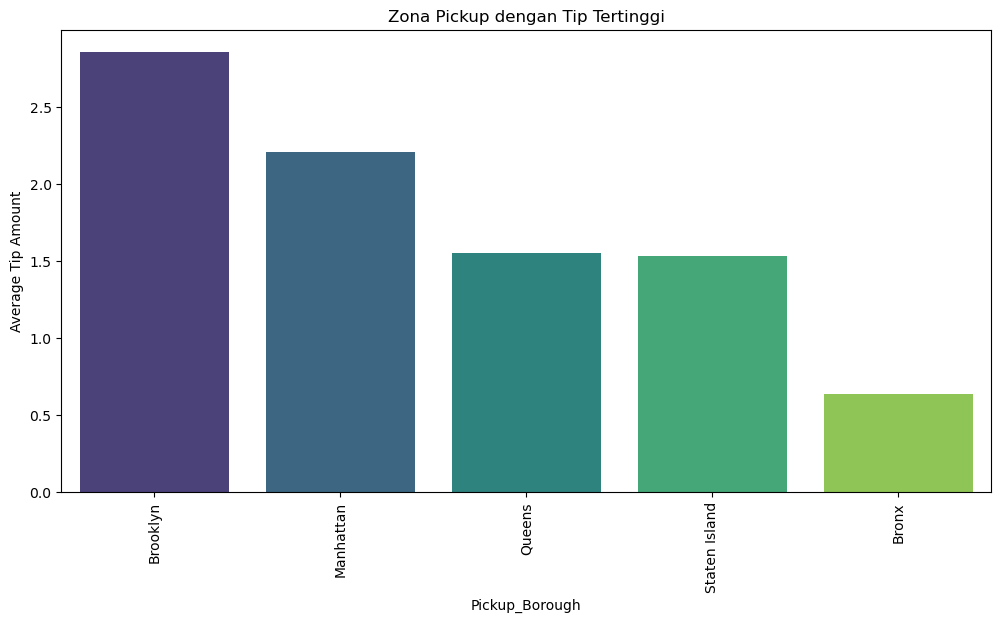

In [164]:
pickup_tip_avg = df_analysis3.groupby('Pickup_Borough')['tip_amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=pickup_tip_avg.index, y=pickup_tip_avg.values, palette='viridis')
plt.title('Zona Pickup dengan Tip Tertinggi')
plt.xlabel('Pickup_Borough')
plt.ylabel('Average Tip Amount')
plt.xticks(rotation=90)
plt.show()

In [165]:
# Simpan data untuk Tableau
pickup_tip_avg.to_csv('pickup_tip_avg.csv', index=False)

> Barplot ini menunjukkan jumlah tip berdasarkan daerah pickup:
> 
> - Menariknya, meskipun tingkat kemacetan tinggi, Brooklyn masih menunjukkan jumlah tip yang tinggi. Ini bisa menunjukkan beberapa hal:
>   * Penghargaan untuk Pengemudi: Penumpang mungkin menghargai usaha pengemudi dalam menghadapi kemacetan dan memberikan tip sebagai bentuk apresiasi.
>   * Perjalanan Jangka Panjang: Meskipun ada kemacetan, penumpang mungkin melakukan perjalanan yang lebih panjang yang secara alami menghasilkan tip yang lebih tinggi.
>   * Faktor Lokal: Brooklyn mungkin memiliki demografi atau budaya yang lebih cenderung memberikan tip lebih besar.
> - Manhattan dan Queens juga memiliki rata-rata tip yang cukup tinggi, meskipun tidak setinggi Brooklyn. Manhattan, sebagai pusat bisnis dan komersial, mungkin memiliki penumpang yang lebih cenderung memberikan tip lebih besar karena tingginya aktivitas ekonomi dan layanan premium yang mungkin tersedia. Queens, dengan variasi demografinya, menunjukkan bahwa ada sebagian penumpang yang juga memberikan tip yang signifikan.
> - Staten Island menunjukkan rata-rata tip yang lebih rendah dibandingkan Brooklyn, Manhattan, dan Queens, tetapi lebih tinggi daripada Bronx. Ini mungkin disebabkan oleh lebih sedikitnya perjalanan atau penumpang yang mungkin memiliki kebiasaan memberikan tip yang lebih rendah.
> - Bronx memiliki rata-rata tip terendah. Ini bisa jadi karena faktor-faktor seperti tingginya kemacetan, pengalaman perjalanan yang kurang nyaman, atau demografi penumpang yang berbeda.

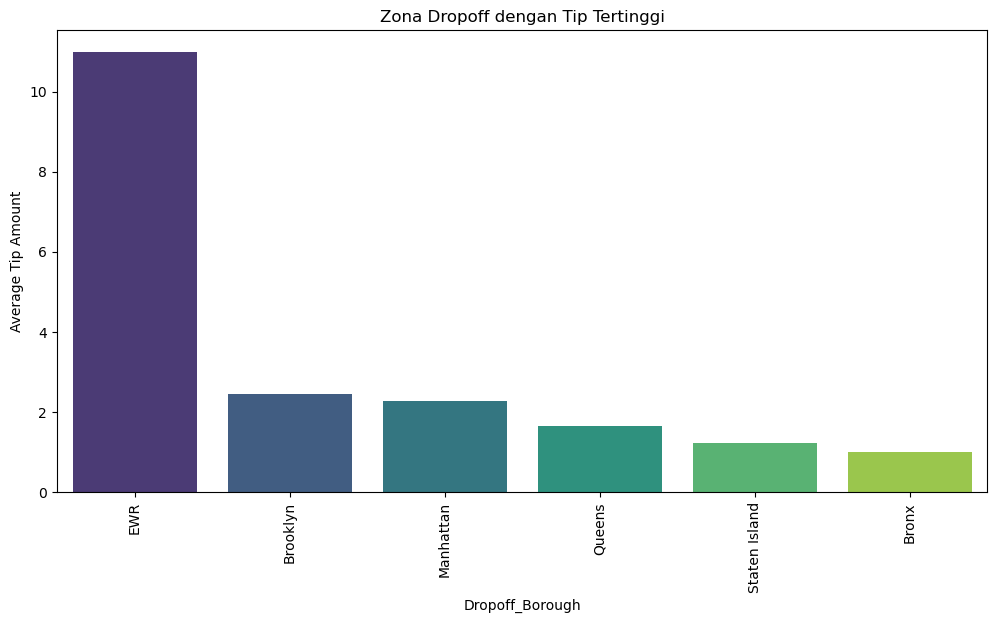

In [167]:
dropoff_tip_avg = df_analysis3.groupby('Dropoff_Borough')['tip_amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=dropoff_tip_avg.index, y=dropoff_tip_avg.values, palette='viridis')
plt.title('Zona Dropoff dengan Tip Tertinggi')
plt.xlabel('Dropoff_Borough')
plt.ylabel('Average Tip Amount')
plt.xticks(rotation=90)
plt.show()

In [168]:
# Simpan data untuk Tableau
dropoff_tip_avg.to_csv('dropoff_tip_avg.csv', index=False)

> Barplot ini menunjukkan jumlah tip berdasarkan daerah pickup:
> 
> - Newark Airport (EWR) menunjukkan rata-rata tip tertinggi, sekitar 10.5. Ini menunjukkan bahwa perjalanan ke bandara cenderung mendapatkan tip yang jauh lebih besar dibandingkan dengan zona lainnya. Penumpang yang bepergian ke bandara mungkin lebih cenderung memberikan tip besar sebagai bentuk apresiasi atas perjalanan yang nyaman atau karena mereka membawa lebih banyak bagasi dan memerlukan lebih banyak bantuan dari pengemudi.
> - Brooklyn dan Manhattan memiliki rata-rata tip yang hampir sama, sekitar 2.5. Ini menunjukkan bahwa penumpang di kedua borough ini cenderung memberikan tip yang cukup tinggi.
> - Queens memiliki rata-rata tip sekitar 2, yang sedikit lebih rendah daripada Brooklyn dan Manhattan tetapi masih cukup signifikan.
> - Staten Island dan Bronx menunjukkan rata-rata tip yang lebih rendah, sekitar 1.5 dan 1.2. Ini mungkin disebabkan oleh lebih sedikitnya perjalanan atau demografi penumpang yang kurang cenderung memberikan tip besar.

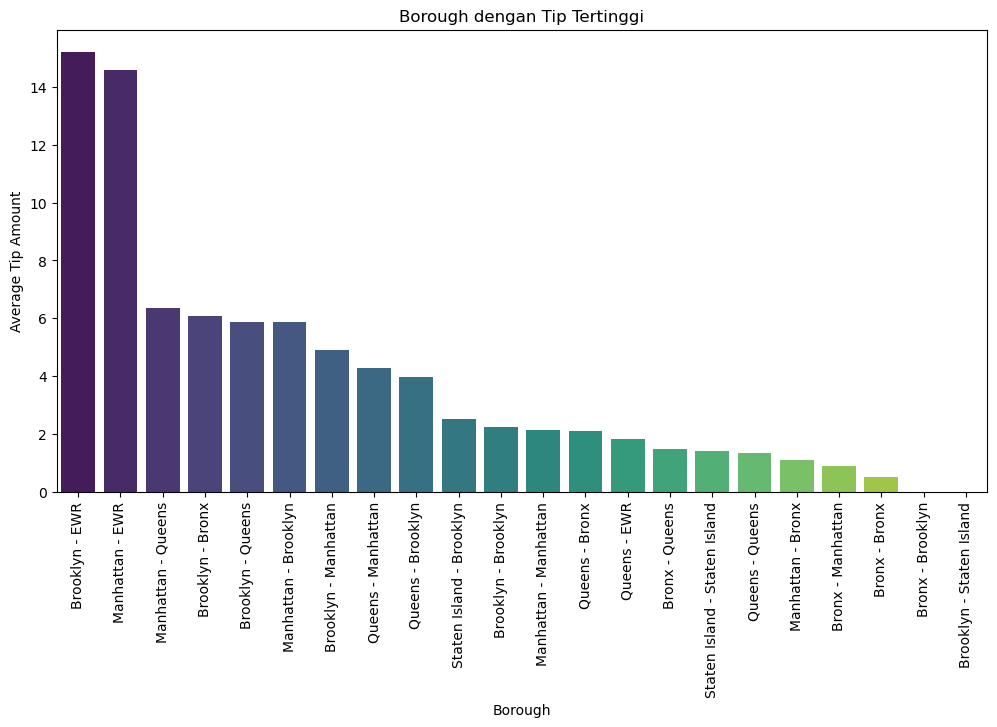

In [284]:
route_tip_avg = df_analysis3.groupby('route_borough')['tip_amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=route_tip_avg.index, y=route_tip_avg.values, palette='viridis')
plt.title('Borough dengan Tip Tertinggi')
plt.xlabel('Borough')
plt.ylabel('Average Tip Amount')
plt.xticks(rotation=90)
plt.show()

In [280]:
# Simpan data untuk Tableau
route_tip_avg = route_tip_avg.reset_index()
route_tip_avg.to_csv('route_tip_avg.csv', index=False)

> Barplot ini menunjukkan jumlah tip berdasarkan daerah pickup:
> 
> - Rute antara Brooklyn ke EWR (Newark Liberty International Airport) dan Manhattan ke EWR memiliki jumlah tip rata-rata tertinggi, keduanya melebihi 14. Ini menunjukkan bahwa pelanggan cenderung memberikan tip lebih besar untuk perjalanan menuju atau dari bandara.
> - Brooklyn dan Manhattan memiliki rata-rata tip yang hampir sama, sekitar 2.5. Ini menunjukkan bahwa penumpang di kedua borough ini cenderung memberikan tip yang cukup tinggi.
> - Queens memiliki rata-rata tip sekitar 2, yang sedikit lebih rendah daripada Brooklyn dan Manhattan tetapi masih cukup signifikan.
> - Staten Island dan Bronx menunjukkan rata-rata tip yang lebih rendah, sekitar 1.5 dan 1.2. Ini mungkin disebabkan oleh lebih sedikitnya perjalanan atau demografi penumpang yang kurang cenderung memberikan tip besar.

# Penutup

Setelah melalui serangkaian analisis data yang mendalam dan mempertimbangkan berbagai faktor yang mempengaruhi hasil yang diperoleh, telah ditemukan sejumlah kesimpulan yang memberikan gambaran yang lebih jelas mengenai kondisi dan tren terkait pernyataan masalah yang telah kita definisikan di awal. Kemudian dari informasi ini harapannya, rekomendasi yang saya berikan berdasarkan data yang ada dapat bermanfaat dalam membantu stakeholder dalam mencapai tujuan awal dilakukannya analisa.

## Kesimpulan

**1.** Secara kumulatif, volume perjalanan pada dataset NYC TLC Trip Record menunjukkan bahwa jam tersibuk berada pada pukul 3 hingga pukul 6 sore. Pada jam sibuk ini akan banyak permintaan taksi, terlebih pada tiga daerah dengan volume perjalanan terbanyak.

**2**. Dari tren harian, kita dapat menyimpulkan bahwa pada hari kerja permintaan taksi jauh meningkat, dan permintaan cenderung menurun pada saat hari libur.

**3.** Dari hasil analisa per daerah, wilayah Brooklyn memperlihatkan tren turunnya kecepatan dengan sangat signifikan dibandingkan dengan daerah lain. Hal ini dapat menjadi indikator bahwa pada daerah Brooklyn terjadi kemacetan yang lebih padat ketimbang daerah lainnya

**4.** Durasi perjalanan tidak serta merta berpengaruh terhadap jumlah tip yang diberikan.

**5.** Terdapat korelasi positif antara jarak tempuh dan jumlah tip yang diberikan, namun dengan variasi yang beragam juga mengindikasi bahwa terdapat faktor selain jarak tempuh yang memengaruhi jumlah tip.

**6.** Titik penjemputan di daerah Brooklyn secara konsisten memiliki jumlah tip yang tinggi sepanjang hari dibandingkan daerah lainnya.
      
**7.** Titik antar Newark Airport (EWR) menunjukkan rata-rata tip tertinggi. Ini menunjukkan bahwa perjalanan ke bandara cenderung mendapatkan tip yang jauh lebih besar dibandingkan dengan zona lainnya.

## Rekomendasi

**1. Pola Waktu Sibuk**
- **Penjadwalan Armada:** Dengan mengetahui jam sibuk, NYC TLC dapat merencanakan penambahan armada pada waktu-waktu tersebut untuk menghindari kepadatan atau kekurangan kendaraan, sehingga permintaan dapat ditemukan dengan suplai yang tepat.
- **Distribusi Armada:** Armada dapat ditempatkan lebih efisien di area yang membutuhkan lebih banyak kendaraan selama jam sibuk seperti daerah Manhattan pada jam 3 hingga 4 sore, dengan distribusi yang lebih efisien dapat mengurangi waktu tunggu bagi pelanggan.

**2. Daerah Dengan Tingkat Kemacetan Tinggi**
- **Penjadwalan Rute yang Lebih Efisien:** Dengan mengetahui zona yang sering macet, TLC dapat membantu pengemudi taksi atau layanan ride-sharing untuk memilih rute yang lebih efisien, mengurangi waktu perjalanan dan mempercepat layanan kepada pelanggan.
- **Dynamic Pricing (Tarif Variabel):** Dalam zona yang sering macet, permintaan lebih tinggi dan waktu perjalanan lebih lama. TLC bisa mendorong penerapan tarif lebih tinggi selama jam-jam tertentu (misalnya, surge pricing) untuk mencocokkan permintaan dan mengimbangi peningkatan waktu tempuh dan biaya operasional.

**3. Jumlah Tip**
- **Program Loyalitas untuk Penumpang:** Mendorong penumpang yang sering menggunakan layanan taksi untuk memberikan tip melalui program loyalitas yang menawarkan diskon atau hadiah lainnya. Dengan program semacam ini, penumpang merasa lebih terikat untuk memberi tip karena mereka merasa dihargai dan mendapatkan manfaat lebih dari layanan yang mereka gunakan.
- **Perencanaan Rute dan Layanan:** Dengan mengetahui rute-rute yang cenderung mendapatkan tip tinggi, perusahaan transportasi dapat merencanakan rute dan layanan yang lebih menguntungkan serta meningkatkan kualitas layanan pada rute-rute tersebut.
- **Kebijakan Tarif:** Wawasan tentang perilaku tipping bisa digunakan untuk menyesuaikan kebijakan tarif, terutama untuk rute dengan tip tinggi atau rendah. Misalnya, mungkin bisa dipertimbangkan untuk menawarkan promosi atau diskon pada rute-rute dengan tip rendah.